In [1]:
!pip install xgboost

In [2]:
!pip install imbalanced-learn
!pip install xgboost
!pip install catboost

!pip install lightgbm

In [3]:
!pip install catboost

In [4]:
!pip show catboost

Name: catboost
Version: 1.2.7
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\Satyam\anaconda3\Lib\site-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 


In [5]:
!pip install lightgbm

In [6]:
!pip install seaborn

In [7]:
import sklearn
print(sklearn.__version__)


1.2.2


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [9]:
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, accuracy_score)
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
# from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, accuracy_score)
# from sklearn.metrics import plot_precision_recall_curve, plot_roc_curve
from sklearn.metrics import ConfusionMatrixDisplay

# from sklearn.metrics import plot_confusion_matrix
import scipy, joblib

In [11]:
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [12]:
df.shape

(3276, 10)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [14]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [15]:
df.isnull().sum() / len(df) * 100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [16]:
df[df.duplicated()]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability


## Exploratory Data Analysis

## Univariate Analysis

ph
Skewness: 0.025630447632210205
Kurtosis: 0.7203155798283807


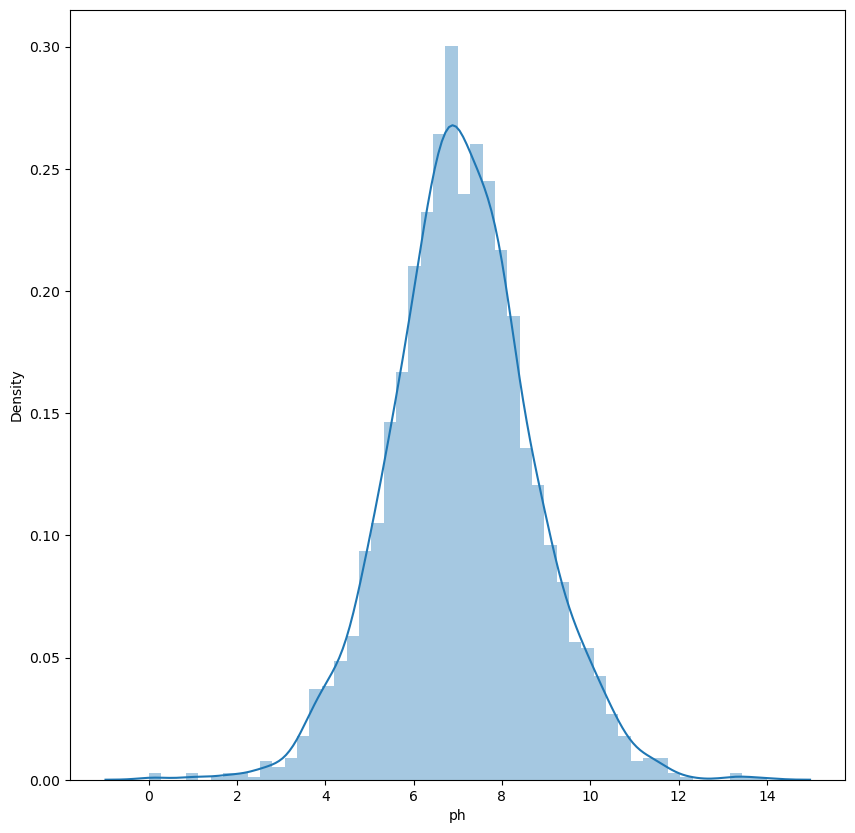

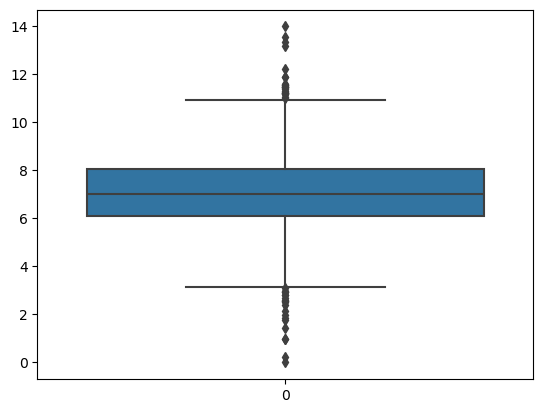

Hardness
Skewness: -0.0393417047767249
Kurtosis: 0.6157716821342123


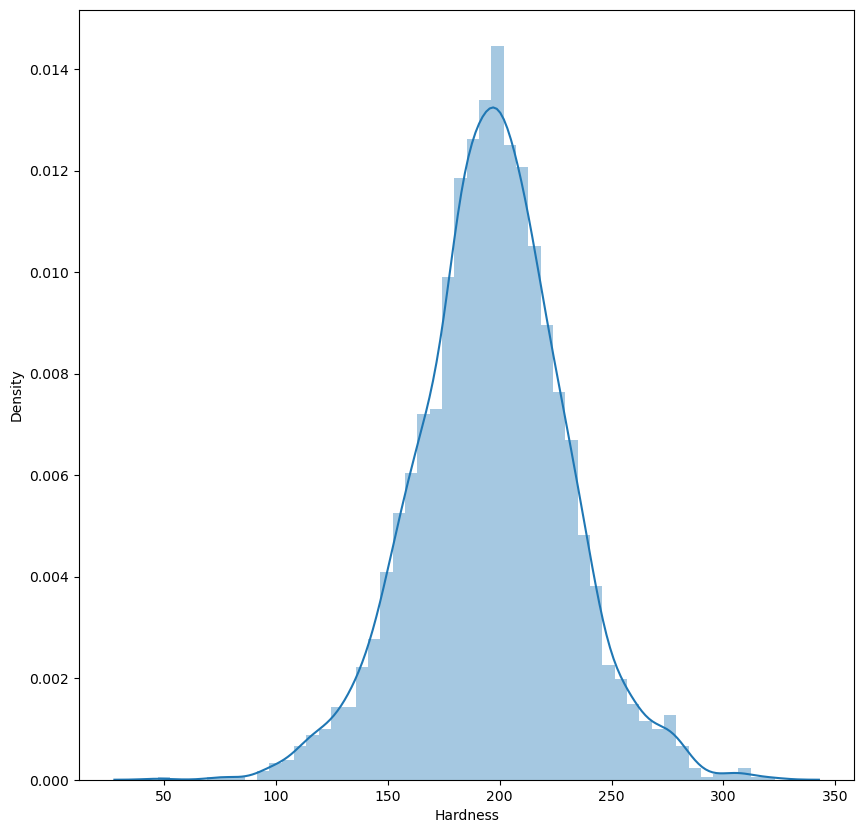

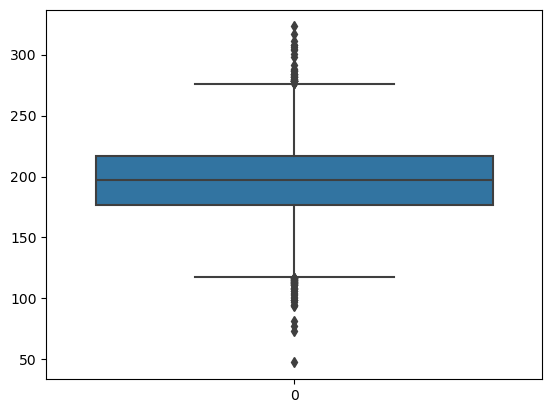

Solids
Skewness: 0.6216344855169127
Kurtosis: 0.4428260857797124


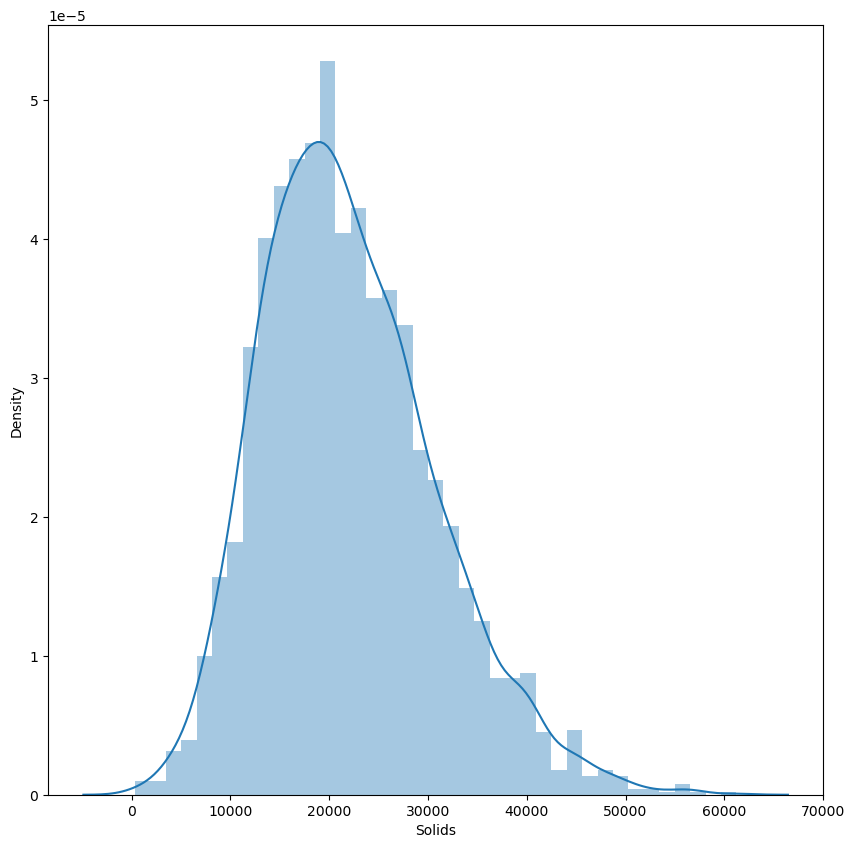

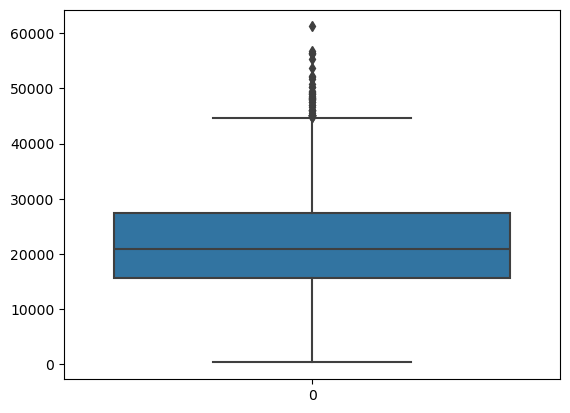

Chloramines
Skewness: -0.01209844012438221
Kurtosis: 0.5899011685623812


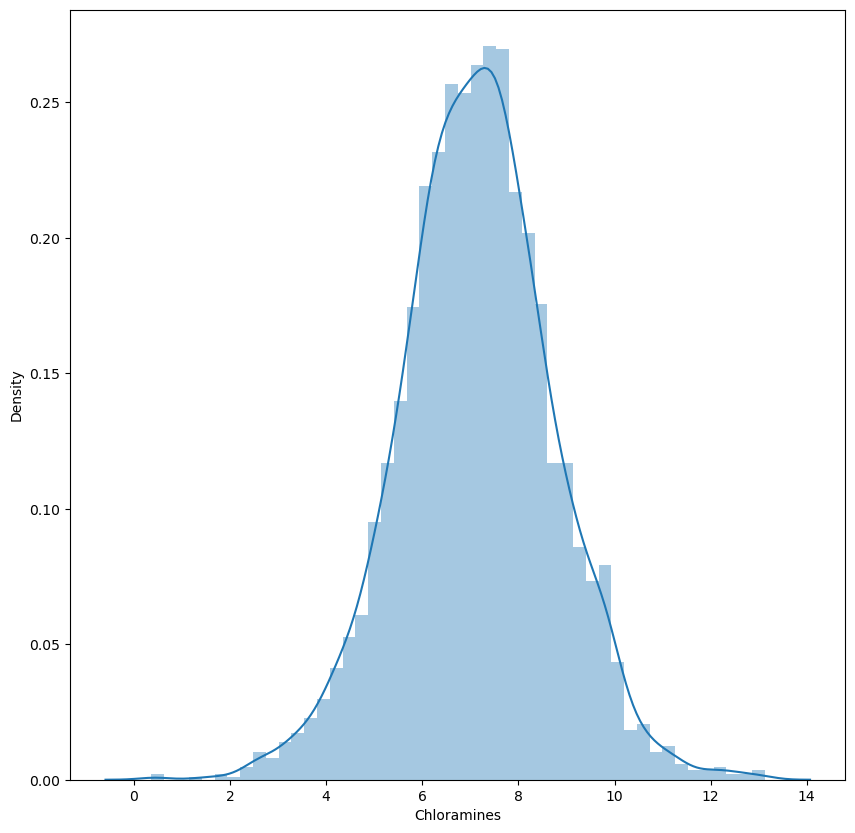

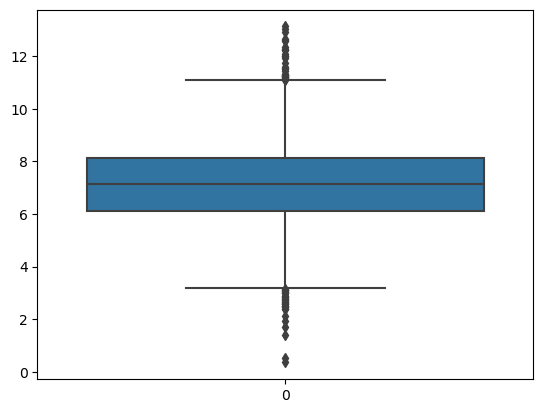

Sulfate
Skewness: -0.03594662160706187
Kurtosis: 0.6482628149948058


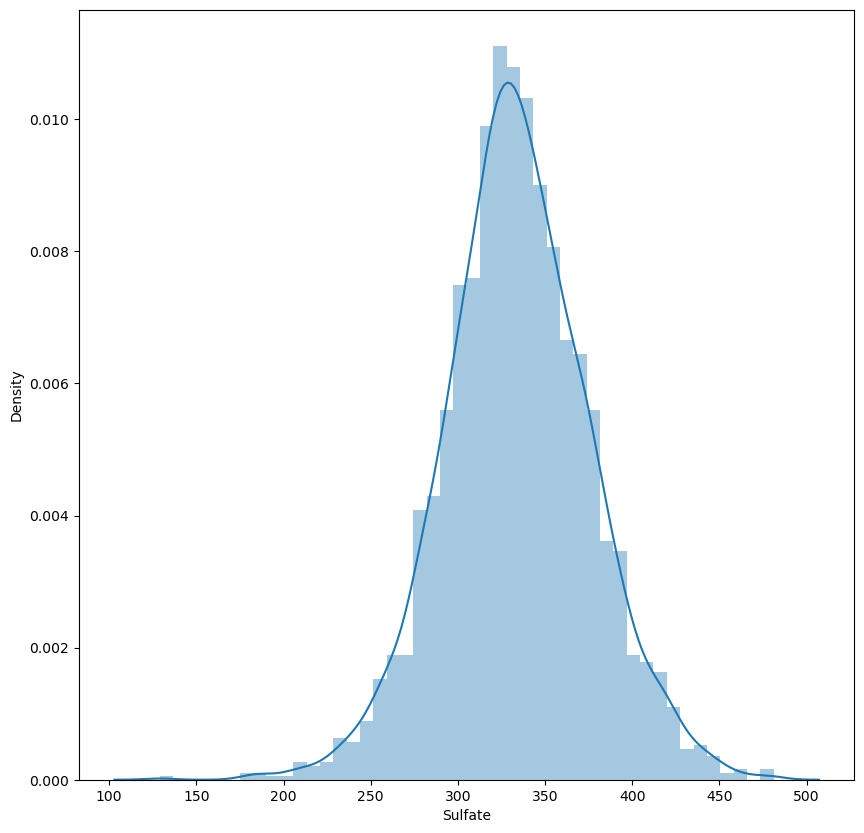

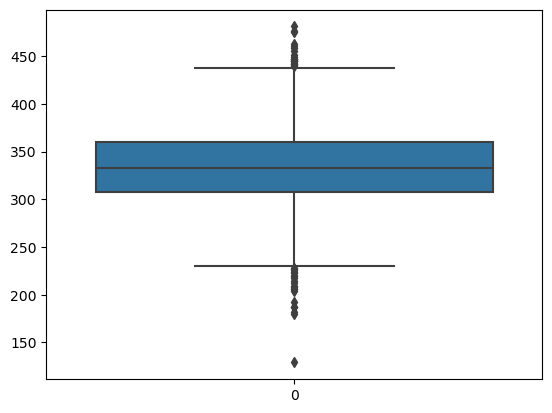

Conductivity
Skewness: 0.2644902239264119
Kurtosis: -0.2770928328764719


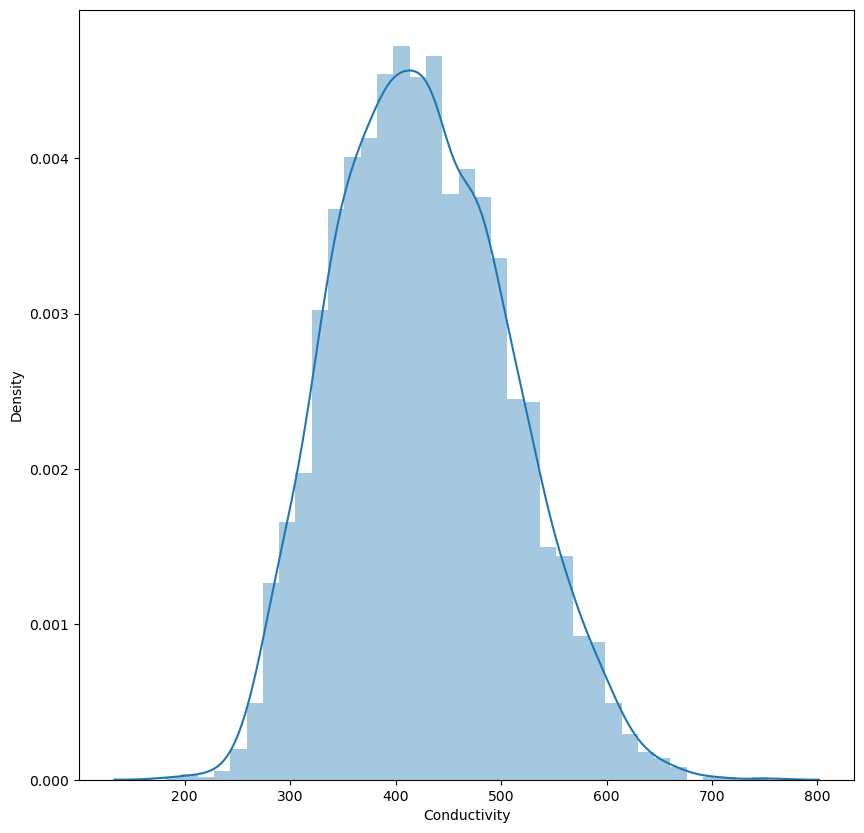

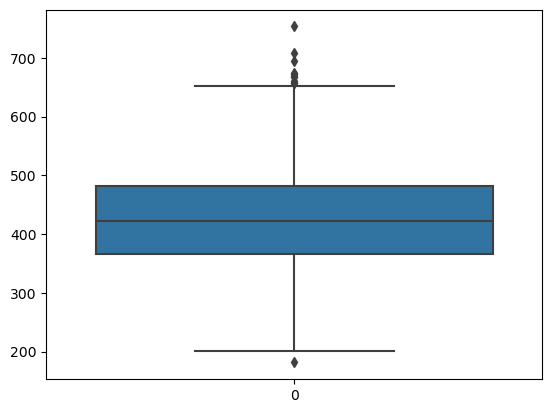

Organic_carbon
Skewness: 0.025532582090242492
Kurtosis: 0.04440930714537439


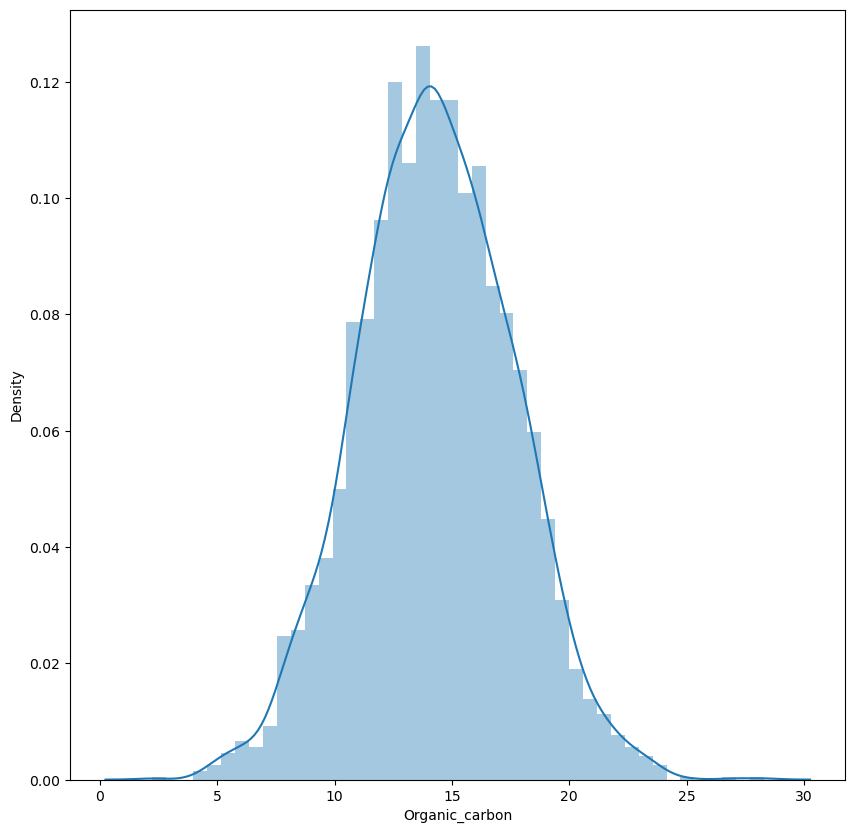

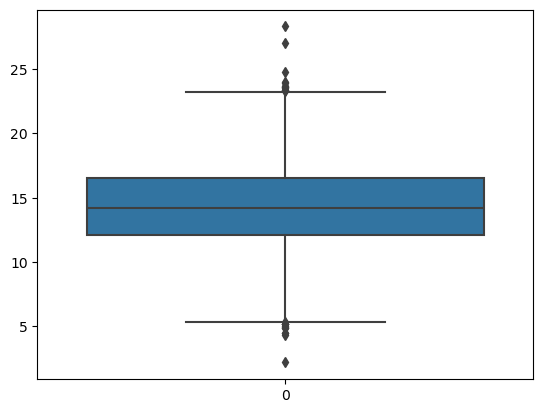

Trihalomethanes
Skewness: -0.08303067407901553
Kurtosis: 0.2385974402088653


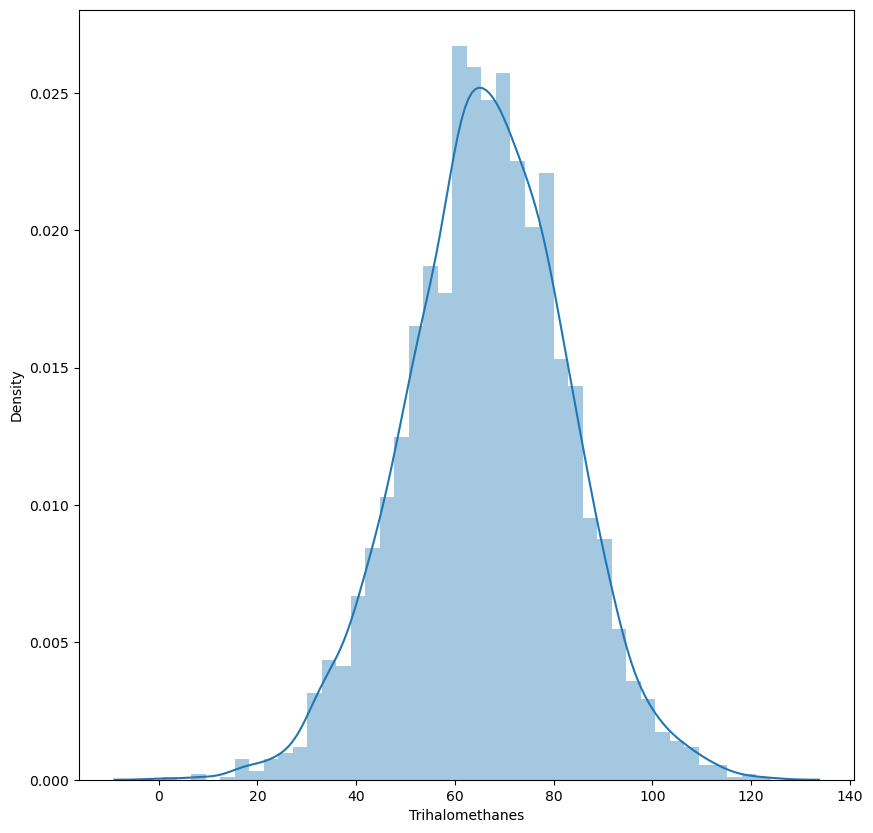

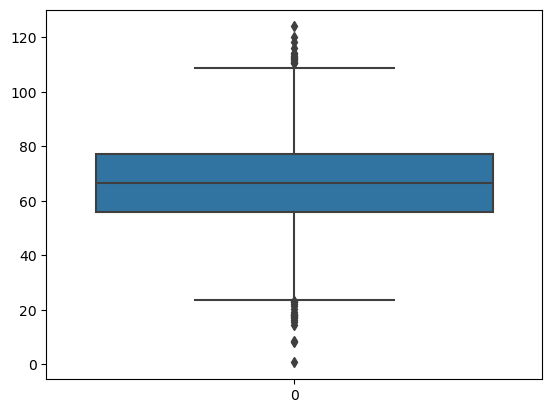

Turbidity
Skewness: -0.007816642377392604
Kurtosis: -0.06280064052220302


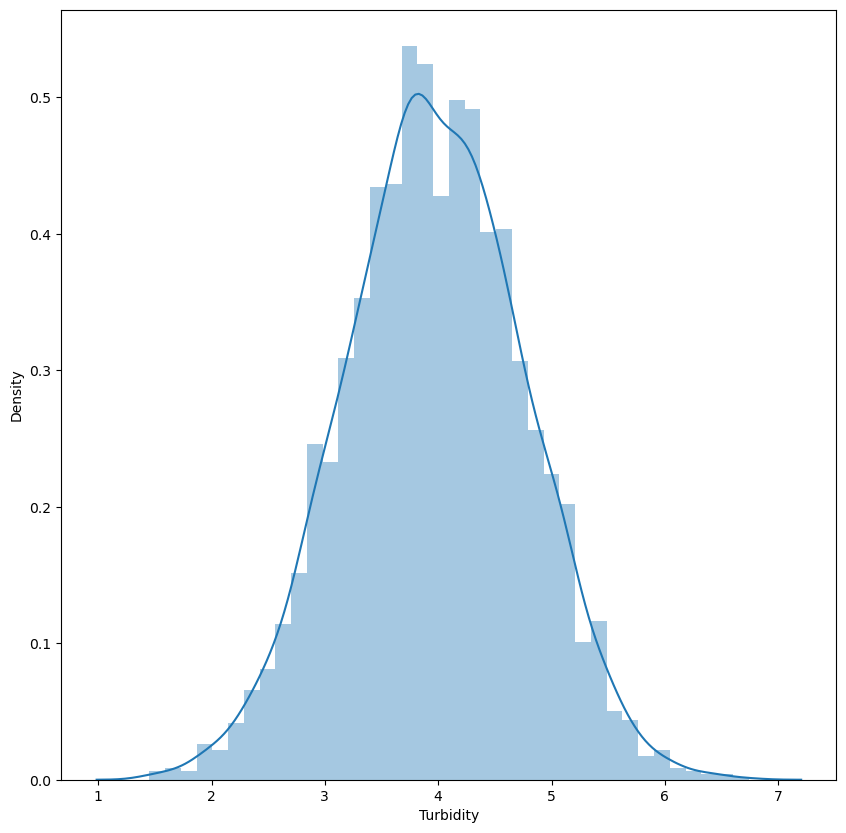

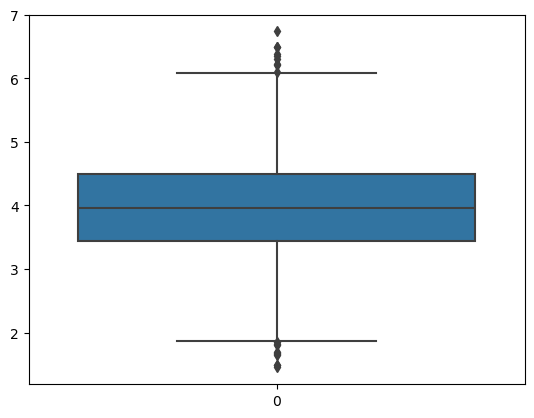

Potability
Skewness: 0.4507837491078628
Kurtosis: -1.7978919987325783


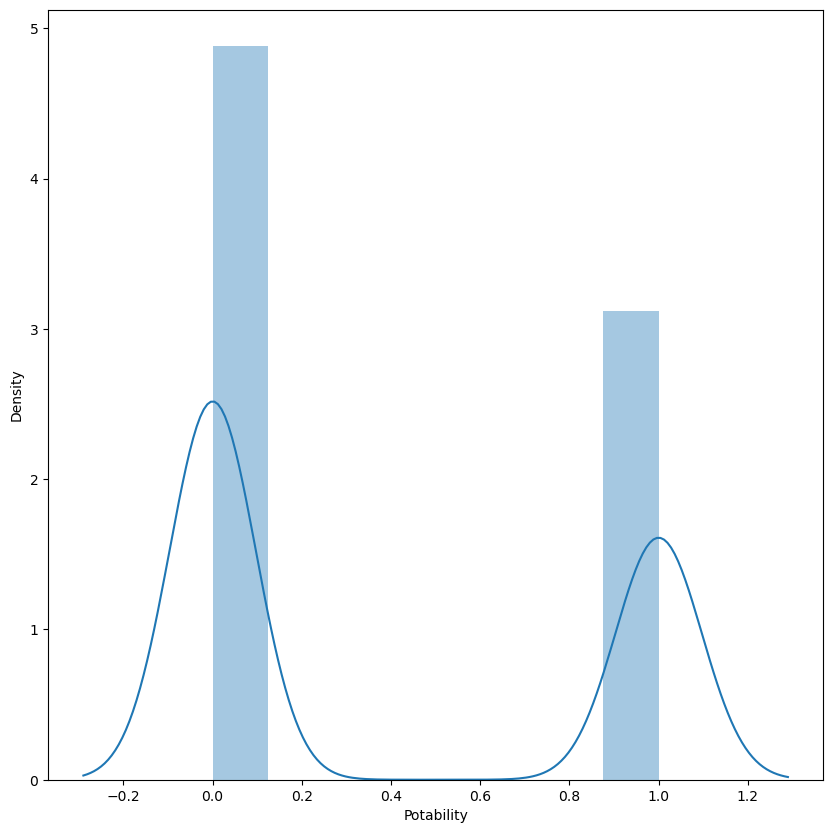

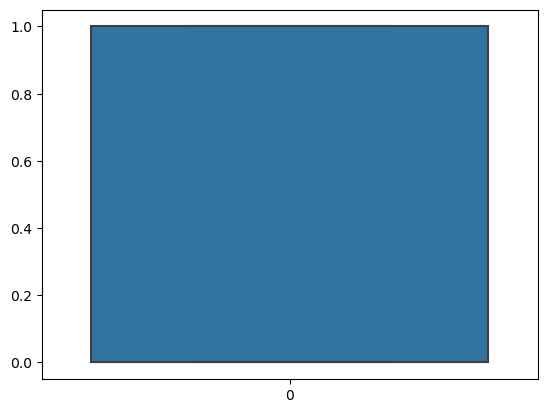

In [17]:
for col in df.columns:
    print(col)
    print("Skewness:",df[col].skew())
    print("Kurtosis:",df[col].kurt())
    plt.figure(figsize=(10,10))
    sns.distplot(df[col])
    plt.show()
    sns.boxplot(df[col])
    plt.show()

The distribution of the features, 'Conductivity' and 'Solids', is considerably skewed. The box plots of each feature indicate the presence of outliers which need to be replaced with some meaningful and acceptable value.

posx and posy should be finite values
posx and posy should be finite values


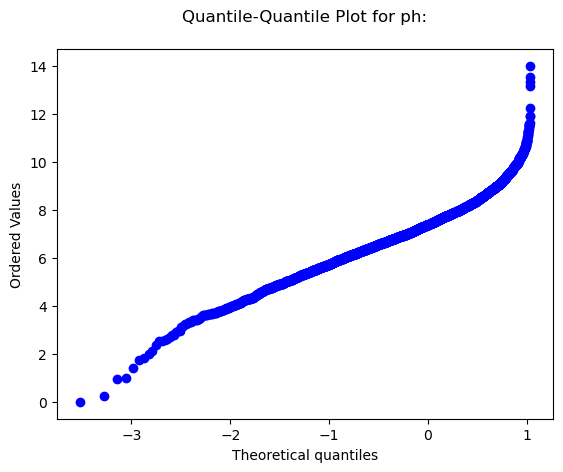

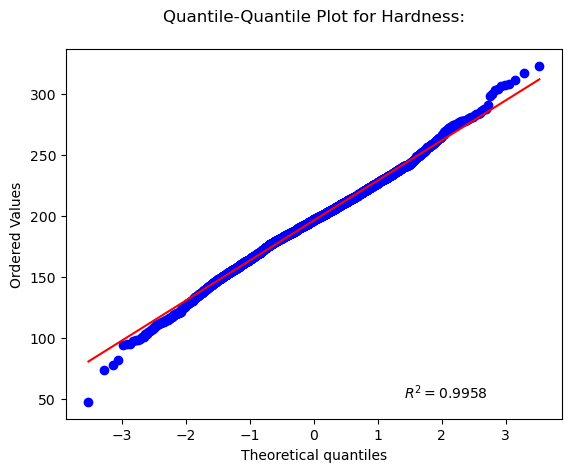

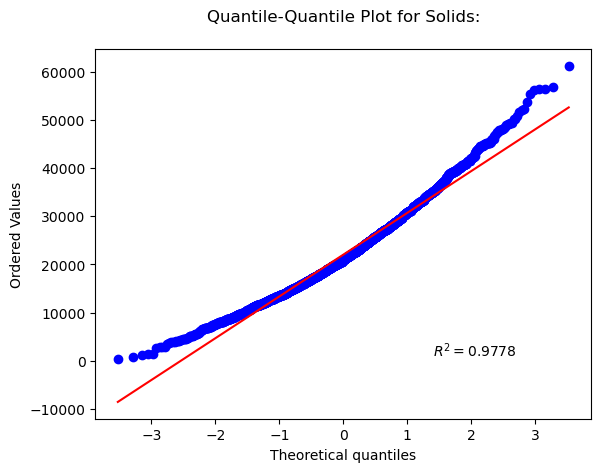

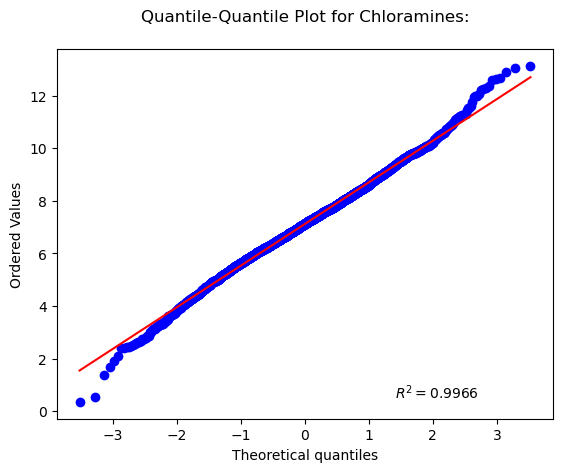

posx and posy should be finite values
posx and posy should be finite values


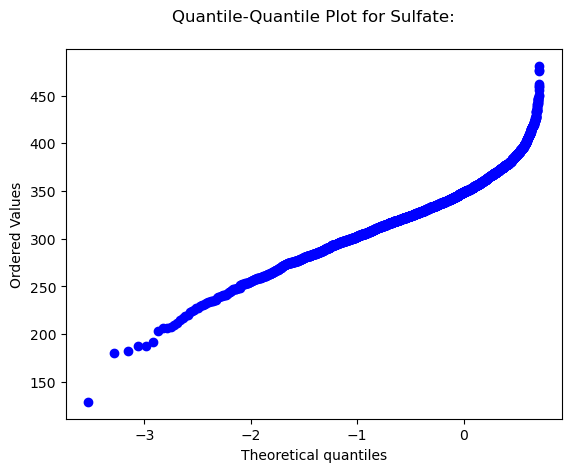

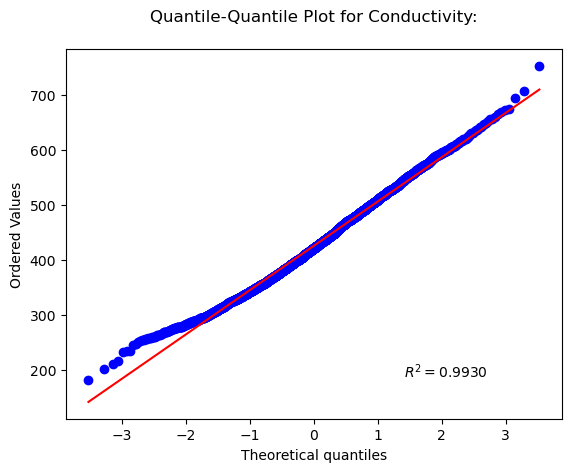

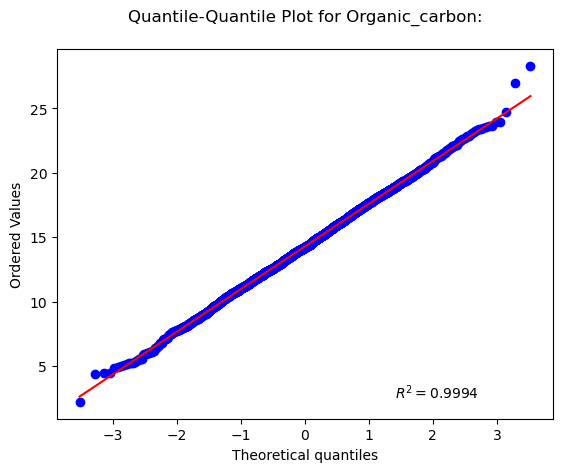

posx and posy should be finite values
posx and posy should be finite values


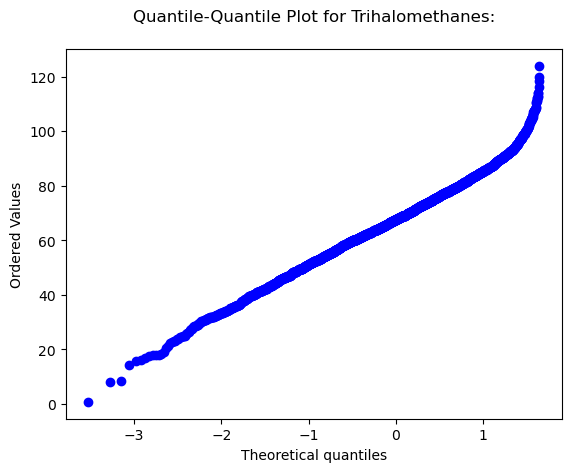

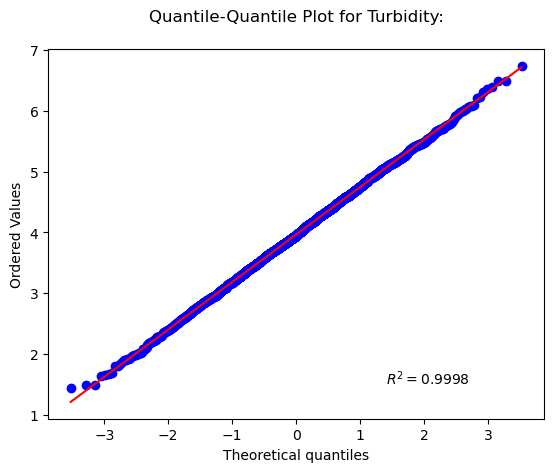

In [18]:
for col in df.columns:
    if col != 'Potability':
        scipy.stats.probplot(df[col],plot=plt,rvalue=True)
        plt.title('Quantile-Quantile Plot for {}:'.format(col),pad=20)
        plt.show()

The distributions of all the features are close to the desired normal distribution.

## Bivariate Analysis

In [19]:
df.corr()['Potability'].sort_values(ascending=False)[1:]

Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64

Statistically speaking, all the features are almost independent of the target column 'Potability'.

However, as far as relative correlation analysis is concerned, solids and chloramines are the features which have the highest correlation with the target label i.e. Potability whereas Organic_carbon is the least significantly correlated with Potability.

In [20]:
df.groupby('Potability')[['Solids','Chloramines','Trihalomethanes','ph','Turbidity','Conductivity','Hardness','Sulfate','Organic_carbon']].mean().reset_index()

,Potability,Solids,Chloramines,Trihalomethanes,ph,Turbidity,Conductivity,Hardness,Sulfate,Organic_carbon
0,0,21777.490788,7.092175,66.303555,7.085378,3.965800,426.730454,196.733292,334.56429,14.364335
1,1,22383.991018,7.169338,66.539684,7.073783,3.968328,425.383800,195.800744,332.56699,14.160893


In [21]:
pd.pivot_table(df,index='Potability',
               values=['Solids','Chloramines','Trihalomethanes','ph','Turbidity','Conductivity','Hardness','Sulfate','Organic_carbon'],
               aggfunc=[np.mean,np.median]
           )

mean                                                        \
           Chloramines Conductivity    Hardness Organic_carbon        Solids   
Potability                                                                     
0             7.092175   426.730454  196.733292      14.364335  21777.490788   
1             7.169338   425.383800  195.800744      14.160893  22383.991018   

                                                               median  \
              Sulfate Trihalomethanes Turbidity        ph Chloramines   
Potability                                                              
0           334.56429       66.303555  3.965800  7.085378    7.090334   
1           332.56699       66.539684  3.968328  7.073783    7.215163   

                                                                              \
           Conductivity    Hardness Organic_carbon        Solids     Sulfate   
Potability                                                                     
0            422.229331  197.123423      14.293508  20809.618280  333.389426   
1            420.712729  196.632907      14.162809  21199.386614  331.838167   

                                                
           Trihalomethanes Turbidity        ph  
Potability                                      
0                66.542198  3.948076  7.035456  
1                66.678214  3.958576  7.036752

## Feature Engineering

### Imputation of Missing Values

In [22]:
for col in ['ph','Sulfate','Trihalomethanes']:
    df[col].fillna(df[col].mean(),inplace=True)

In [23]:
df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

### Outlier Treatment

In [24]:
for col in df.columns:
    if col not in ['ph', 'Potability'] and df[col].dtype in ['float64', 'int64']:  # Ensure numeric columns
        lower_limit, upper_limit = df[col].quantile([0.25, 0.75])  # Get Q1 (lower) and Q3 (upper) quartiles
        
        IQR = upper_limit - lower_limit
        lower_whisker = lower_limit - 1.5 * IQR
        upper_whisker = upper_limit + 1.5 * IQR
        
        # Capping the outliers
        df[col] = np.where(df[col] < lower_whisker, lower_whisker, 
                           np.where(df[col] > upper_whisker, upper_whisker, df[col]))

The target feature Potability has imbalanced classes with 1.0 i.e. potable water being the majority class and 0.0 i.e. non-potable water being the minority class. The minority class needs to be over-sampled using some over sampling technique which will be done later. 

In [25]:
df['Potability'] = df['Potability'].astype('category')


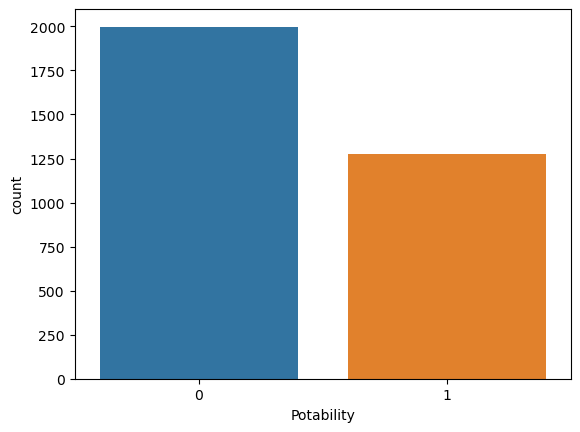

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot for Potability column
sns.countplot(x='Potability', data=df)

# Display the plot
plt.show()


## Multivariate Analysis

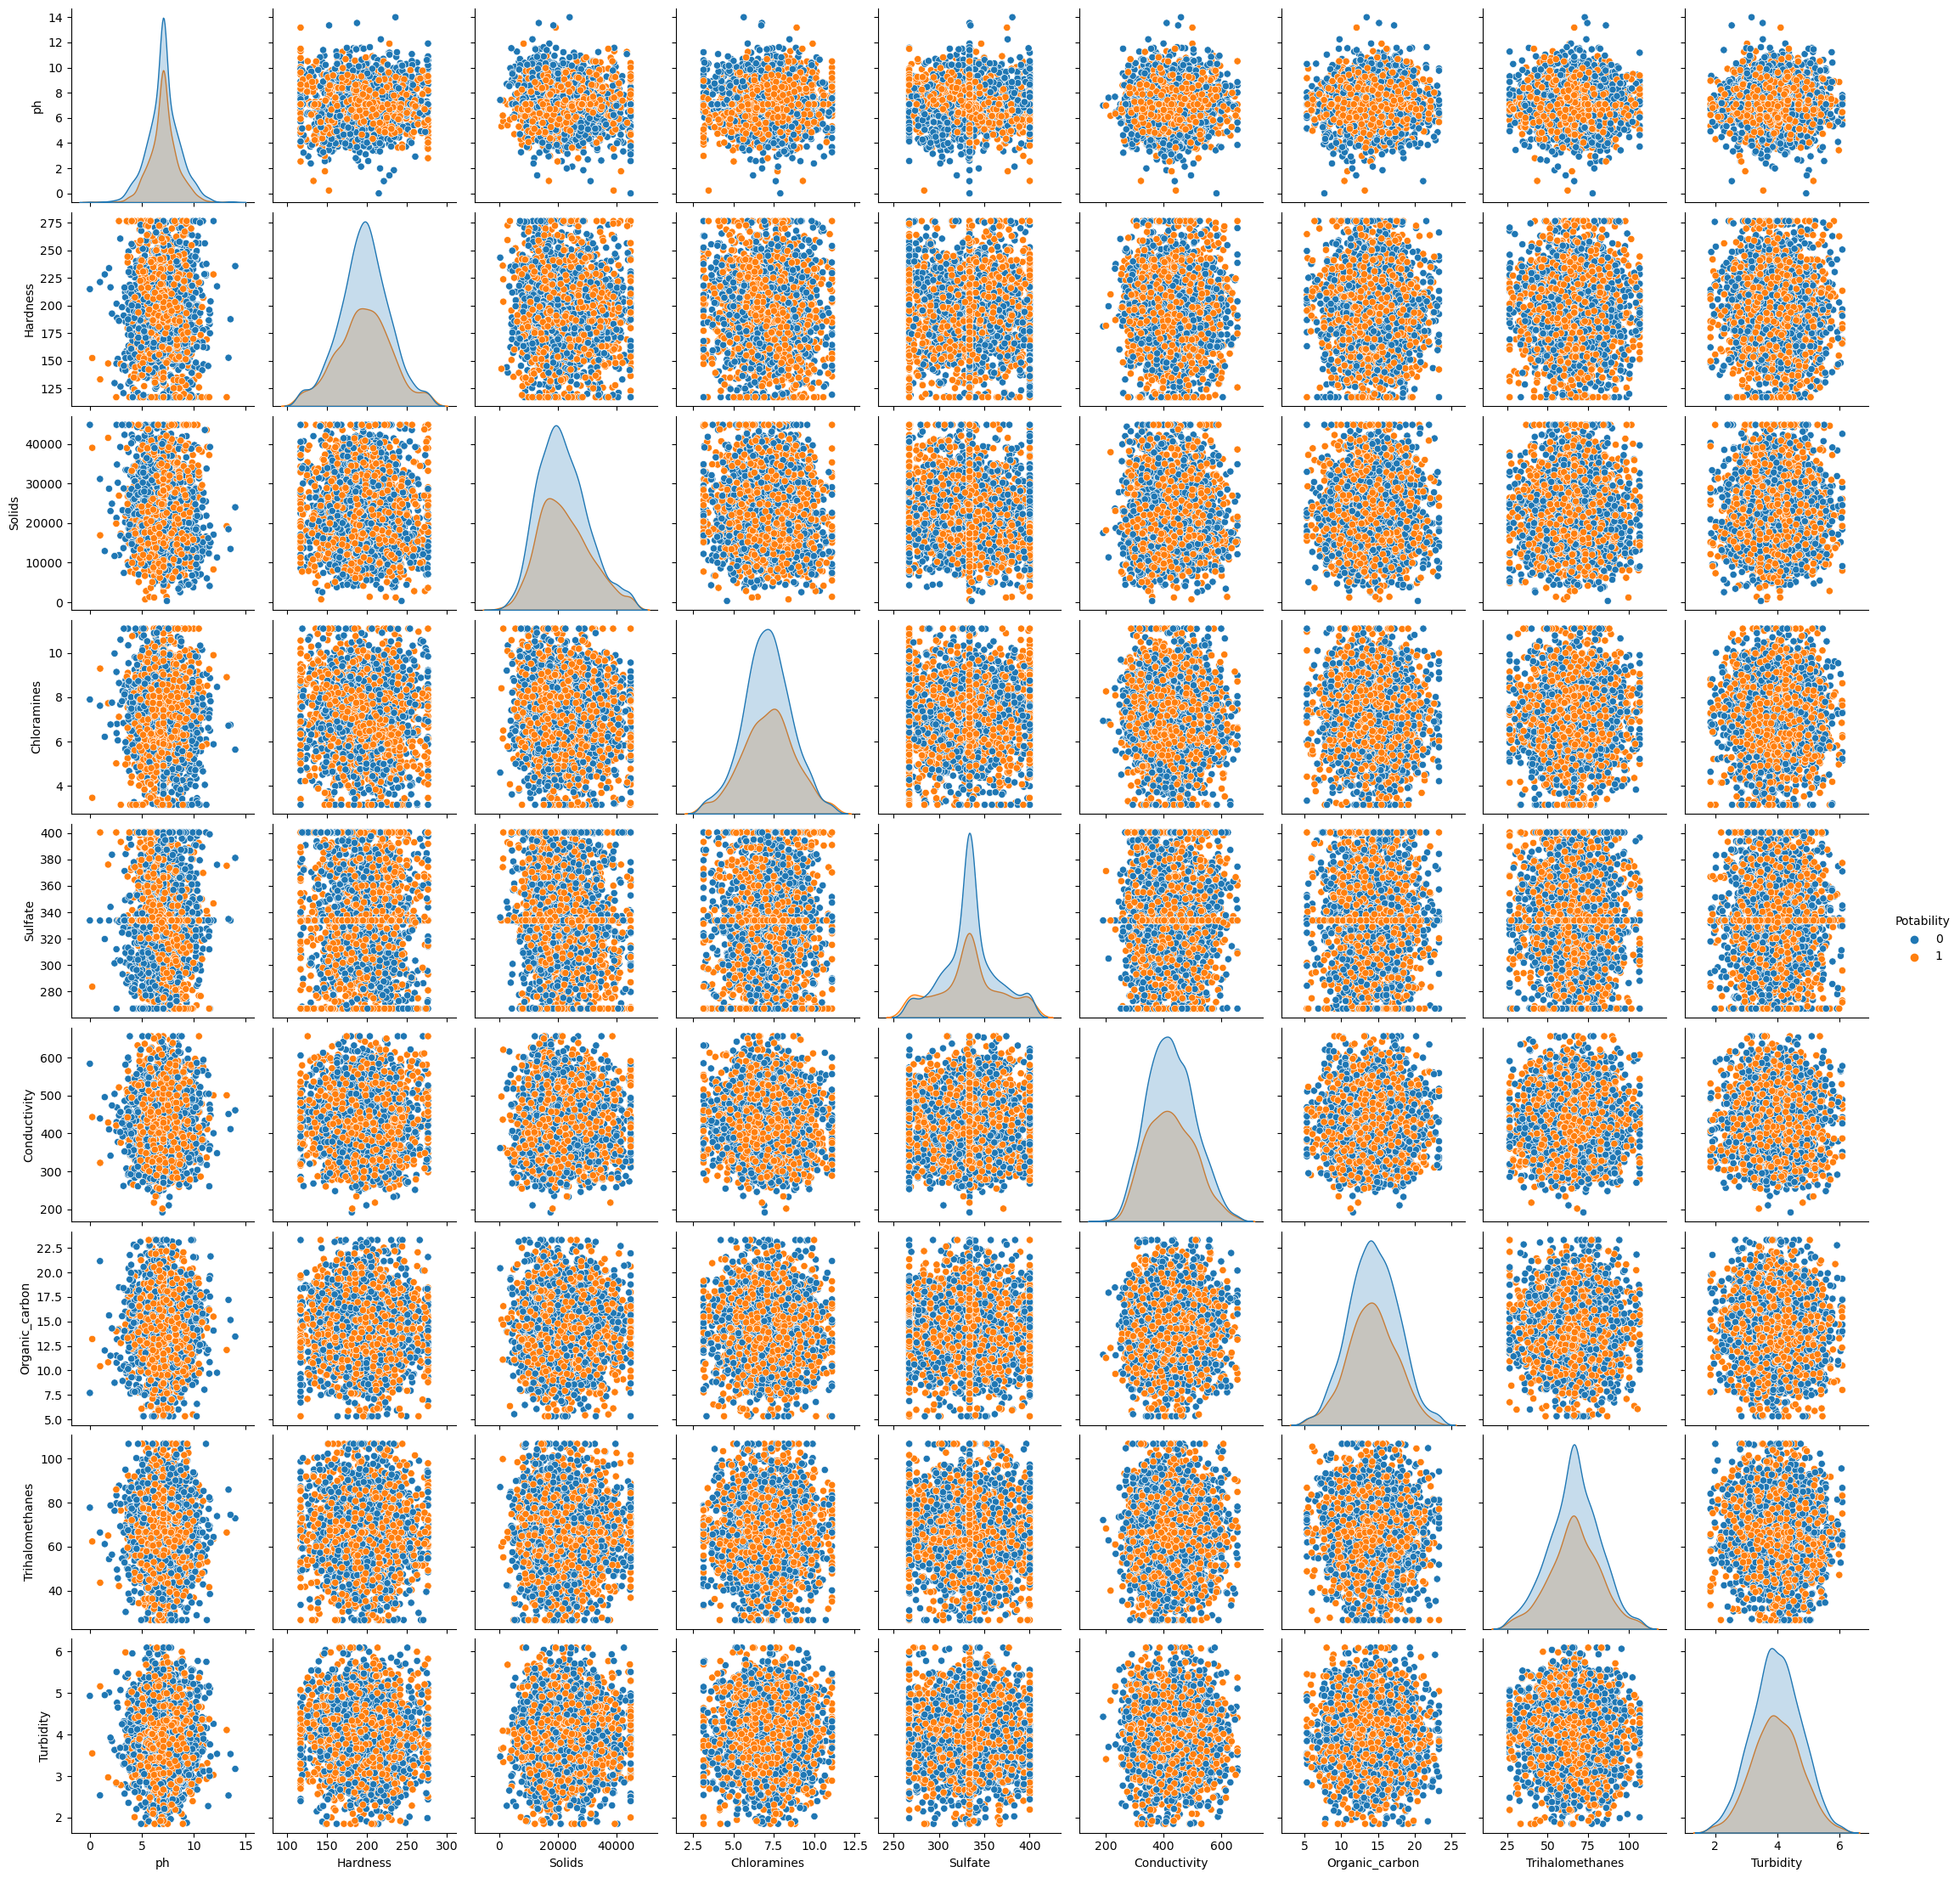

In [27]:
sns.pairplot(df,hue='Potability')

Both potable and non-potable water have almost similar properties and follow Gaussian distribution.

<Axes: >

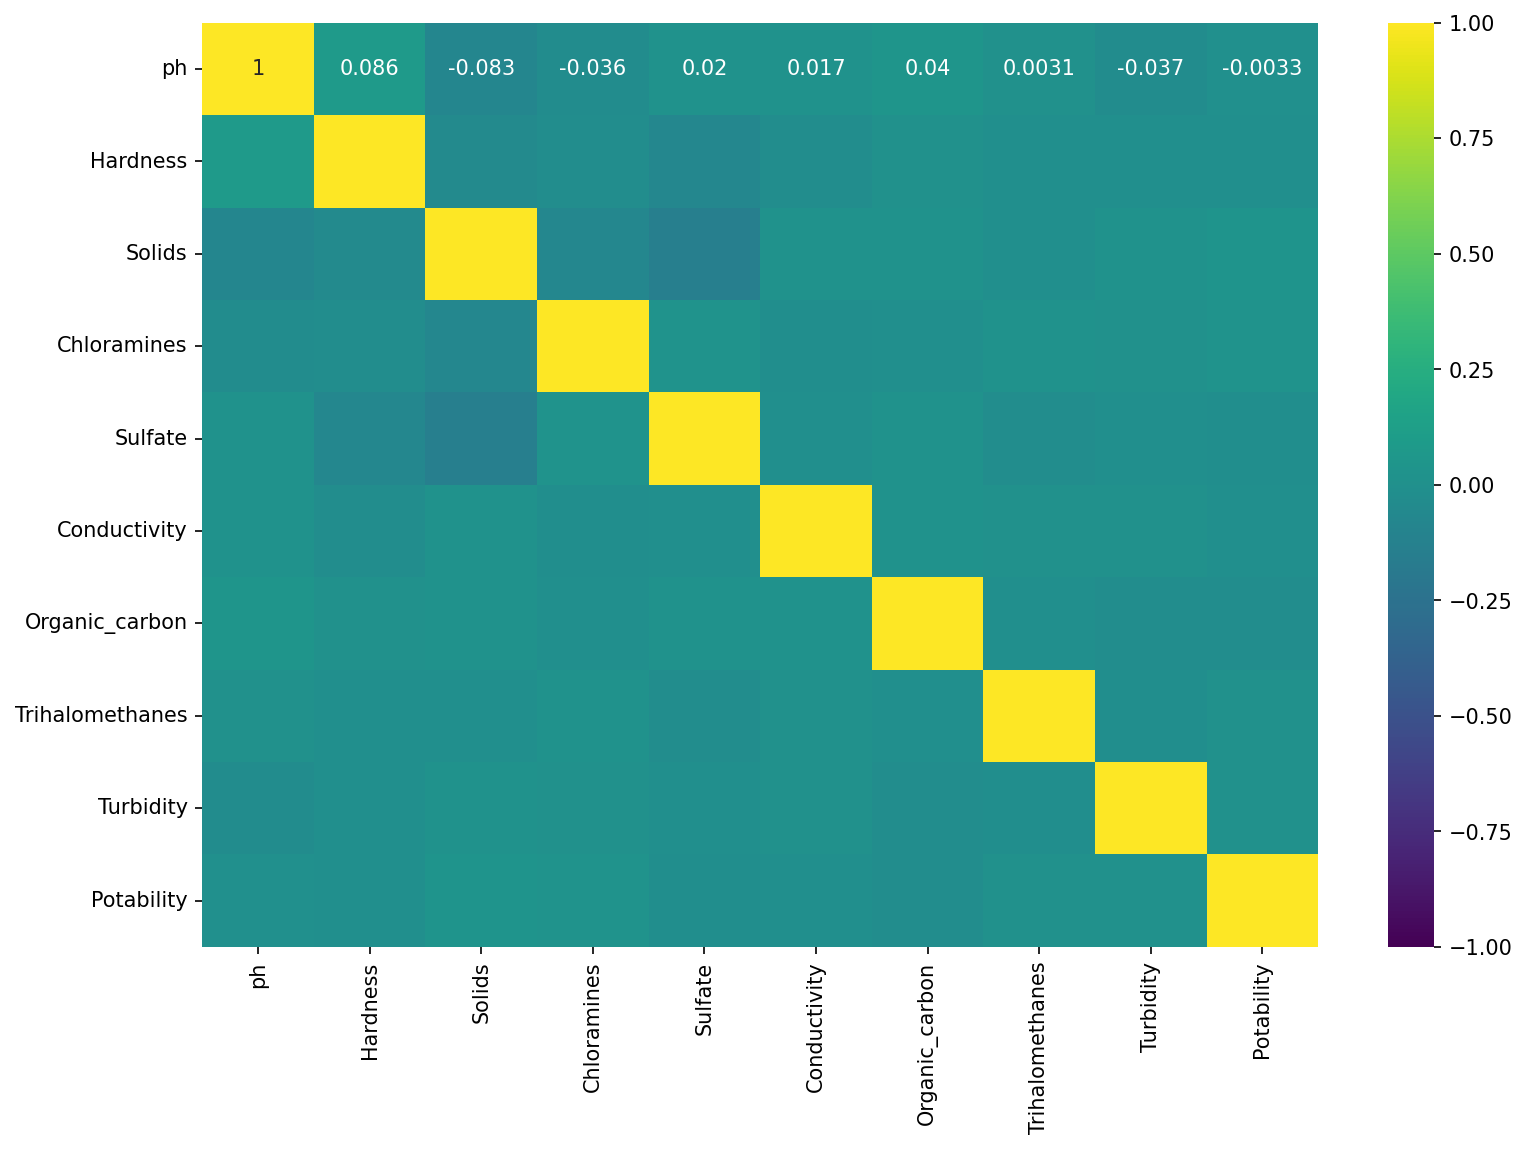

In [28]:
plt.figure(figsize=(12,8),dpi=150)
sns.heatmap(df.corr(),annot=True,cmap='viridis',vmin=-1,vmax=1)

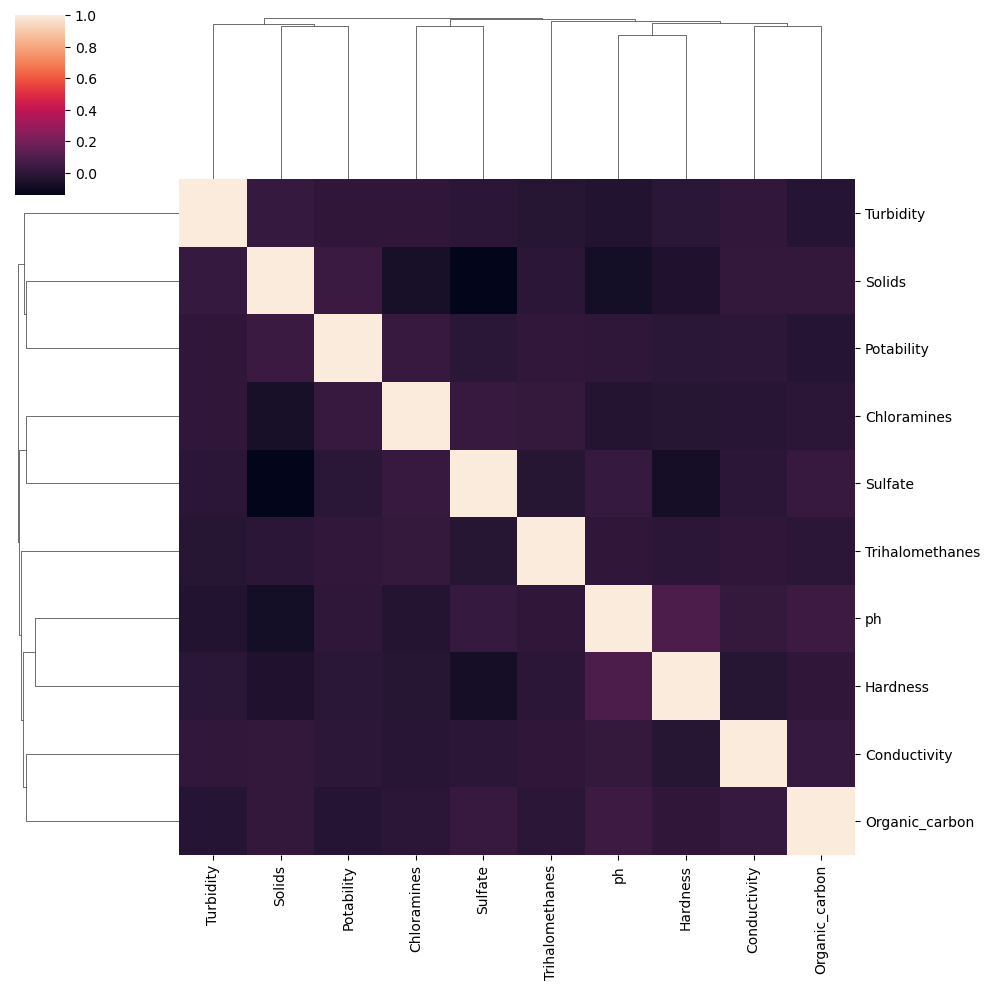

In [29]:
sns.clustermap(df.corr(),)

## Model Training & Evaluation

In [30]:
X = df.drop('Potability',axis=1)
y = df.Potability

## Feature Scaling

In [31]:
scaler = StandardScaler()
features = X.columns
X = scaler.fit_transform(X)
X = pd.DataFrame(X,columns=features)
X.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,-6.043133e-16,0.265461,-0.135691,0.115564,1.093335,1.715401,-1.187299,1.328436,-1.292657
1,-2.289339e+00,-2.091993,-0.387249,-0.315144,-0.000406,2.070162,0.272685,-0.651695,0.687944
2,6.928678e-01,0.869786,-0.238325,1.395235,-0.000406,-0.093403,0.786278,-0.000022,-1.173116
3,8.409504e-01,0.561689,0.007136,0.607257,0.727178,-0.780410,1.263149,2.190618,0.852978
4,1.368569e+00,-0.477657,-0.463030,-0.372561,-0.744666,-0.344116,-0.828861,-2.222985,0.139720


## Balancing the target classes

In [32]:
smote = SMOTE()
X, y = smote.fit_resample(X,y)

## Dividing the dataset into training and test sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

## Logistic Regression

In [34]:
base_log_model = LogisticRegression()
base_log_model.fit(X_train,y_train)

LogisticRegression()

In [35]:
lr_pred = base_log_model.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.50      0.57      0.53       593
           1       0.52      0.45      0.48       606

    accuracy                           0.51      1199
   macro avg       0.51      0.51      0.51      1199
weighted avg       0.51      0.51      0.51      1199



### Cross Validation of Logistic Regression model

In [36]:
cv_log_model = pd.DataFrame(cross_validate(base_log_model,X_train,y_train,scoring=['accuracy','precision','recall','f1','roc_auc'],cv=10,verbose=2))
cv_log_model

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.1s finished


,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.006013,0.014785,0.521429,0.521739,0.431655,0.472441,0.518241
1,0.007093,0.015223,0.532143,0.529851,0.510791,0.520147,0.510485
2,0.004371,0.011298,0.500000,0.496183,0.467626,0.481481,0.538395
3,0.002224,0.008778,0.492857,0.487603,0.424460,0.453846,0.481147
4,0.007105,0.014134,0.464286,0.456000,0.410072,0.431818,0.492474
5,0.004118,0.000000,0.496429,0.496350,0.485714,0.490975,0.516939
6,0.000000,0.022048,0.507143,0.508772,0.414286,0.456693,0.508929
7,0.007713,0.007482,0.526882,0.529412,0.453237,0.488372,0.519013
8,0.000000,0.016469,0.491039,0.488372,0.453237,0.470149,0.510997
9,0.004786,0.005389,0.494624,0.492537,0.474820,0.483516,0.511254


In [37]:
cv_log_model.test_accuracy.mean()

0.5026830517153098

### Searching for appropriate value of no. of neighbors for KNN algorithm

In [38]:
scores = []
for i in range(1,21):
    knc = KNeighborsClassifier(n_neighbors=i)
    knc.fit(X_train,y_train)
    scores.append(knc.score(X_test,y_test))

Text(0, 0.5, 'Accuracy Score')

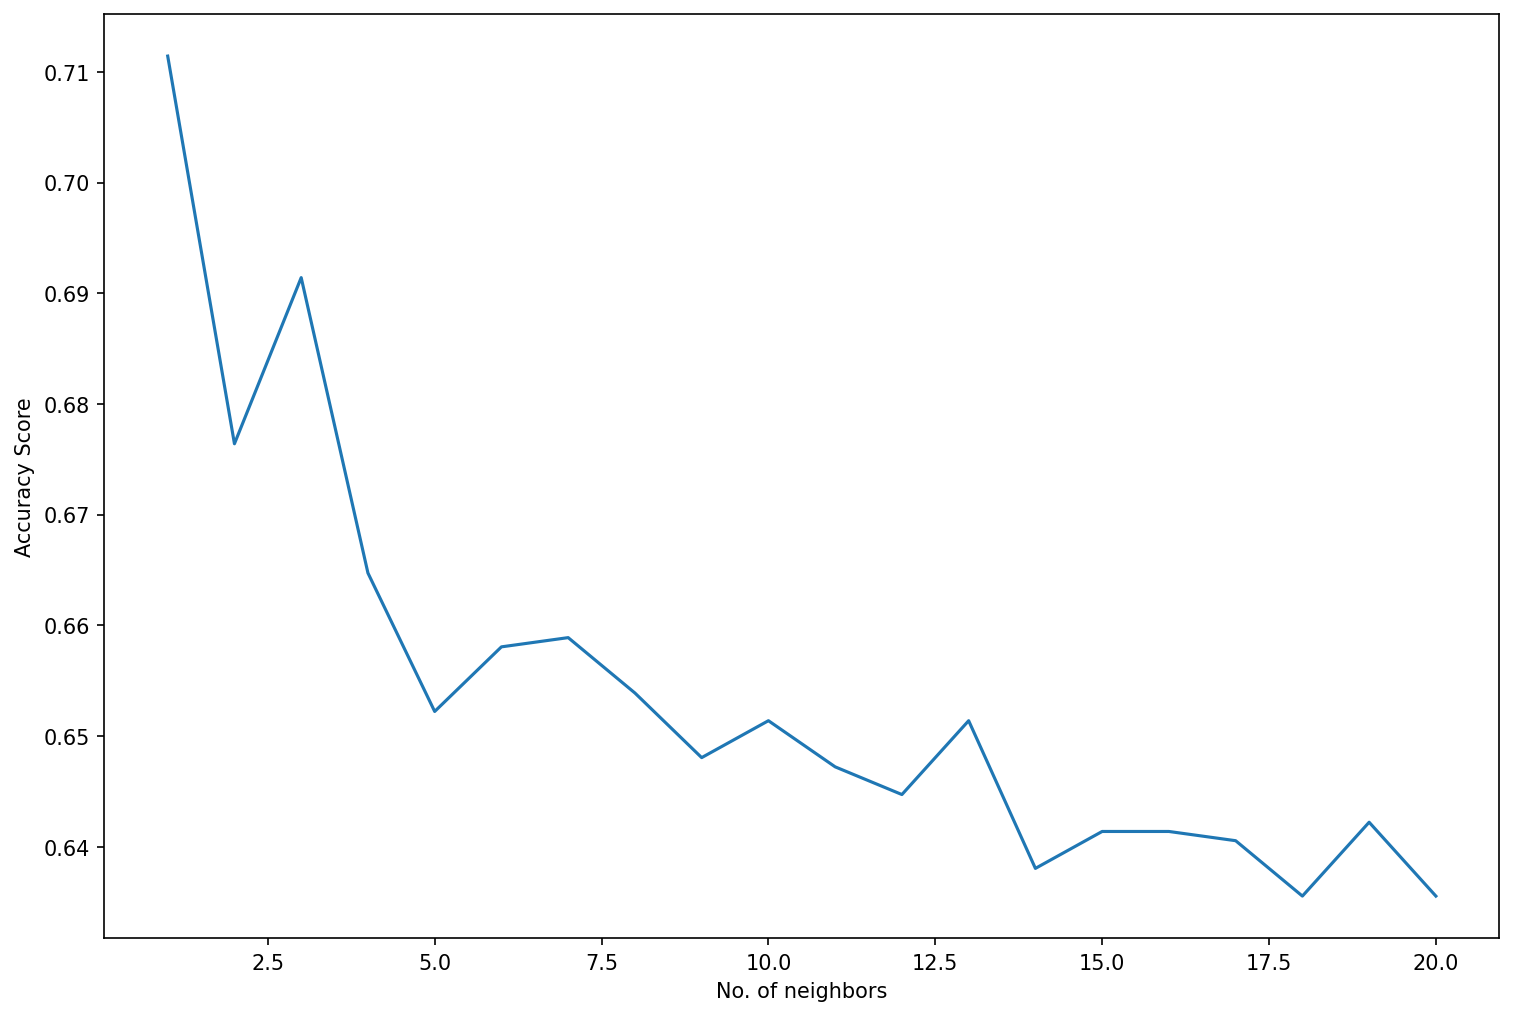

In [39]:
plt.figure(figsize=(12,8),dpi=150)
sns.lineplot(x=range(1, 21), y=scores)
plt.xlabel('No. of neighbors')
plt.ylabel('Accuracy Score')

## K Nearest Neighbors Classifier

In [40]:
knc = KNeighborsClassifier(n_neighbors=1)
knc.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [41]:
knc_pred = knc.predict(X_test)
print(classification_report(y_test,knc_pred))

              precision    recall  f1-score   support

           0       0.75      0.63      0.68       593
           1       0.69      0.79      0.73       606

    accuracy                           0.71      1199
   macro avg       0.72      0.71      0.71      1199
weighted avg       0.72      0.71      0.71      1199



## Support Vector Classifier

In [42]:
svc = SVC()
svc.fit(X_train,y_train)

SVC()

In [43]:
svc_pred = svc.predict(X_test)
print(classification_report(y_test,svc_pred))

              precision    recall  f1-score   support

           0       0.66      0.69      0.68       593
           1       0.68      0.66      0.67       606

    accuracy                           0.67      1199
   macro avg       0.67      0.67      0.67      1199
weighted avg       0.67      0.67      0.67      1199



## Decision Tree Classifier

In [44]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [45]:
dtree_pred = dtree.predict(X_test)
print(classification_report(y_test,dtree_pred))

              precision    recall  f1-score   support

           0       0.61      0.60      0.61       593
           1       0.62      0.63      0.62       606

    accuracy                           0.61      1199
   macro avg       0.61      0.61      0.61      1199
weighted avg       0.61      0.61      0.61      1199



## Searching for suitable value of no. of estimators for Random Forest model

In [46]:
scores = []
for i in range(100,901,100):
    rfc = RandomForestClassifier(n_estimators=i)
    rfc.fit(X_train,y_train)
    scores.append(rfc.score(X_test,y_test))

Text(0, 0.5, 'Accuracy score')

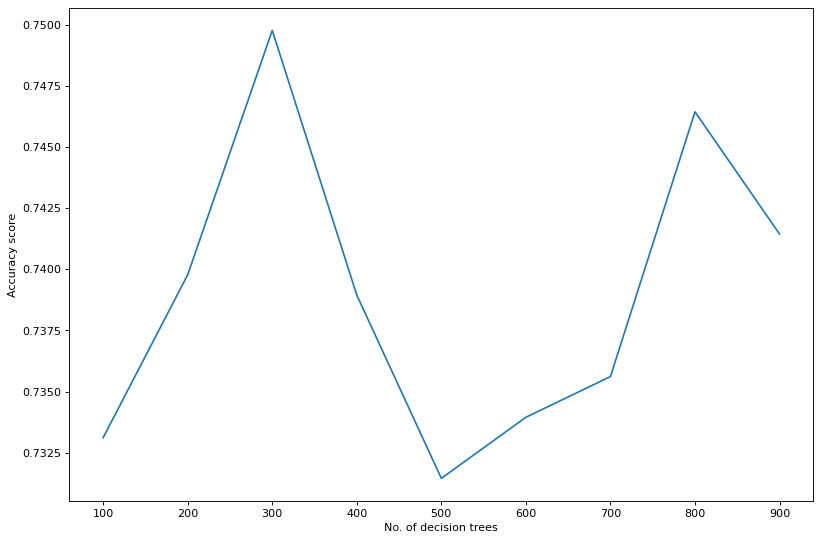

In [47]:
plt.figure(figsize=(12,8),dpi=80)
sns.lineplot(x=range(100, 901, 100), y=scores)  # Use 'x' and 'y' for the axes
plt.xlabel('No. of decision trees')
plt.ylabel('Accuracy score')

In [48]:
temp = pd.concat([pd.Series(range(100,901,100)),pd.Series(scores)],axis=1)
temp.columns = ['No. of estimators','Score']
temp = temp.sort_values('Score',ascending=False)
noe = int(temp.iloc[0]['No. of estimators'])
noe

300

## Random Forest Classifier

In [49]:
rfc = RandomForestClassifier(n_estimators=noe)
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=300)

In [50]:
rfc_pred = rfc.predict(X_test)
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.71      0.77      0.74       593
           1       0.76      0.70      0.73       606

    accuracy                           0.74      1199
   macro avg       0.74      0.74      0.74      1199
weighted avg       0.74      0.74      0.74      1199



In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


[[459 134]
 [183 423]]


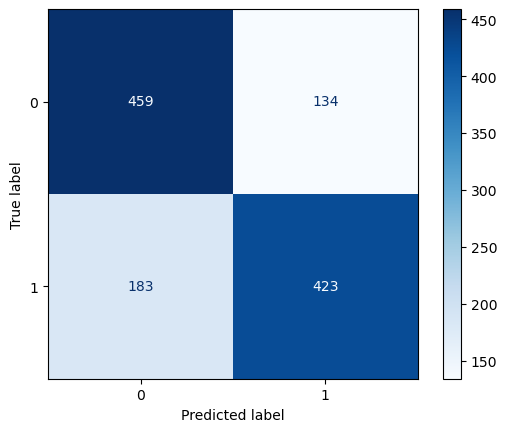

In [52]:
print(confusion_matrix(y_test,rfc_pred))
conf_matrix = confusion_matrix(y_test, rfc_pred)

# Display confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=rfc.classes_)
disp.plot(cmap='Blues')

# Show the plot
plt.show()

In [53]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay


In [54]:
y_prob = rfc.predict_proba(X_test)[:, 1]


In [55]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

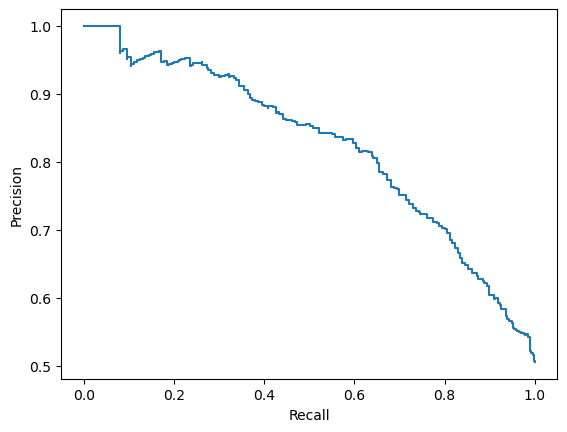

In [56]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_prob = rfc.predict_proba(X_test)[:, 1]

# Compute precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Create PrecisionRecallDisplay object
disp = PrecisionRecallDisplay(precision=precision, recall=recall)

# Plot precision-recall curve (without 'cmap')
disp.plot()

# Display the plot
plt.show()


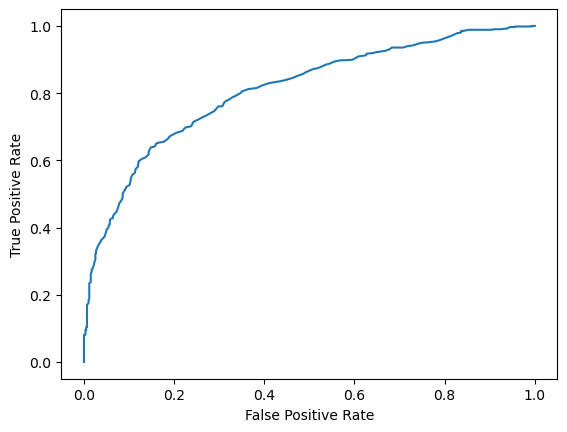

In [57]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_prob = rfc.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Create and plot the ROC curve
disp = RocCurveDisplay(fpr=fpr, tpr=tpr)
disp.plot()

# Show the plot
plt.show()


## Feature Importance

<Axes: xlabel='Importance', ylabel='Feature'>

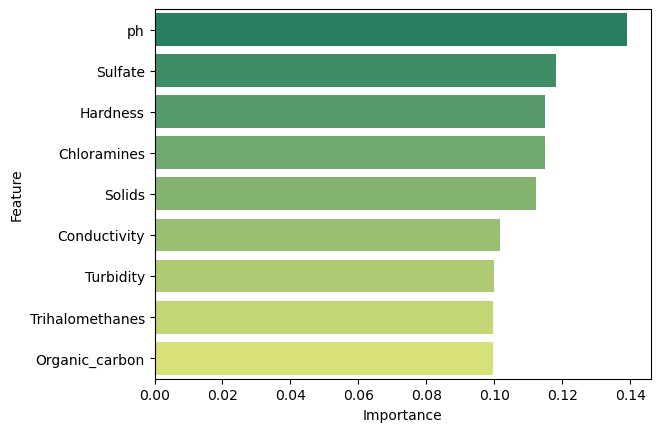

In [58]:
temp = pd.concat([pd.Series(features),pd.Series(rfc.feature_importances_)],axis=1)
temp.columns = ['Feature','Importance']
temp = temp.sort_values('Importance',ascending=False)
sns.barplot(x='Importance',y='Feature',data=temp,orient='h',palette='summer')

ph is the most signficant feature whereas trihalomethanes is the least important feature.

## XG Boost Classifier

In [59]:
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [60]:
xgb_pred = xgb.predict(X_test)
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.68      0.69      0.68       593
           1       0.69      0.68      0.69       606

    accuracy                           0.68      1199
   macro avg       0.68      0.68      0.68      1199
weighted avg       0.68      0.68      0.68      1199



## Gradient Boosting Classifier

In [61]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train,y_train)

GradientBoostingClassifier()

In [62]:
gbc_pred = gbc.predict(X_test)
print(classification_report(y_test,gbc_pred))

              precision    recall  f1-score   support

           0       0.63      0.68      0.65       593
           1       0.66      0.61      0.63       606

    accuracy                           0.64      1199
   macro avg       0.64      0.64      0.64      1199
weighted avg       0.64      0.64      0.64      1199



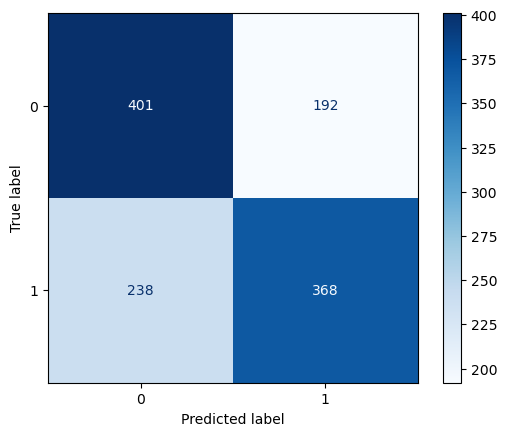

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, gbc.predict(X_test))

# Create ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=gbc.classes_)

# Plot the confusion matrix
disp.plot(cmap='Blues')  # Optional: You can change the color map here

# Show the plot
plt.show()


## Gaussian Naive Bayes

In [64]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

[[376 217]
 [307 299]]


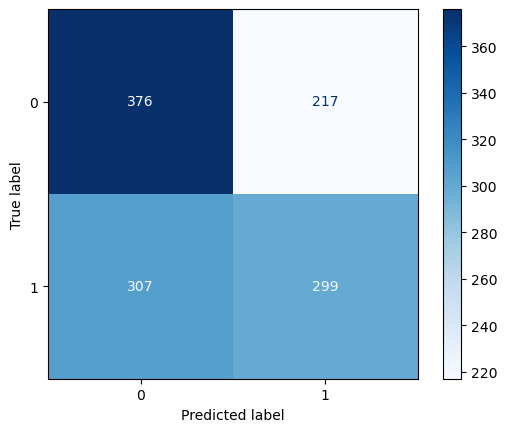

              precision    recall  f1-score   support

           0       0.55      0.63      0.59       593
           1       0.58      0.49      0.53       606

    accuracy                           0.56      1199
   macro avg       0.56      0.56      0.56      1199
weighted avg       0.57      0.56      0.56      1199



In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Make predictions using Gaussian Naive Bayes
gnb_pred = gnb.predict(X_test)

# Print confusion matrix
print(confusion_matrix(y_test, gnb_pred))

# Create and plot confusion matrix using ConfusionMatrixDisplay
conf_matrix = confusion_matrix(y_test, gnb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=gnb.classes_)
disp.plot(cmap='Blues')  # Optional: You can change the color map here

# Show the plot
plt.show()

# Print classification report
print(classification_report(y_test, gnb_pred))


## Bernoulli Naive Bayes

In [66]:
bnb = BernoulliNB()
bnb.fit(X_train,y_train)

BernoulliNB()

[[316 277]
 [318 288]]


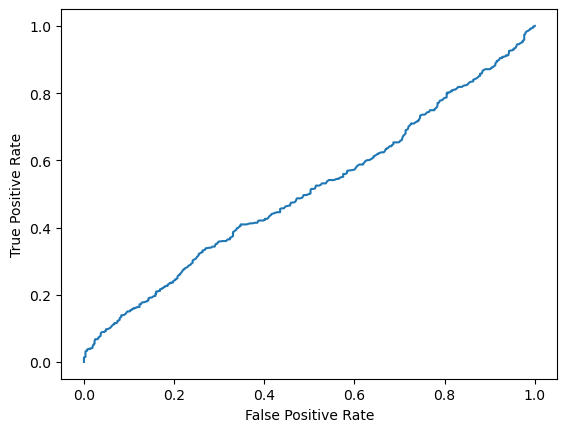

              precision    recall  f1-score   support

           0       0.50      0.53      0.52       593
           1       0.51      0.48      0.49       606

    accuracy                           0.50      1199
   macro avg       0.50      0.50      0.50      1199
weighted avg       0.50      0.50      0.50      1199



In [67]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Make predictions using Bernoulli Naive Bayes
bnb_pred = bnb.predict(X_test)

# Print confusion matrix
print(confusion_matrix(y_test, bnb_pred))

# Get predicted probabilities for the positive class
y_prob = bnb.predict_proba(X_test)[:, 1]  # For binary classification, use the second column

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve using RocCurveDisplay
disp = RocCurveDisplay(fpr=fpr, tpr=tpr)
disp.plot()

# Show the plot
plt.show()

# Print classification report
print(classification_report(y_test, bnb_pred))


## SGD Classifier

In [68]:
sgd = SGDClassifier()
sgd.fit(X_train,y_train)

SGDClassifier()

In [69]:
sgd_pred = sgd.predict(X_test)
print(classification_report(y_test,sgd_pred))

              precision    recall  f1-score   support

           0       0.50      0.76      0.60       593
           1       0.53      0.27      0.35       606

    accuracy                           0.51      1199
   macro avg       0.51      0.51      0.48      1199
weighted avg       0.52      0.51      0.48      1199



## Ridge Classifier

In [70]:
ridge = RidgeClassifier()
ridge.fit(X_train,y_train)

RidgeClassifier()

In [71]:
ridge_pred = ridge.predict(X_test)
print(classification_report(y_test,ridge_pred))

              precision    recall  f1-score   support

           0       0.50      0.57      0.53       593
           1       0.52      0.45      0.48       606

    accuracy                           0.51      1199
   macro avg       0.51      0.51      0.51      1199
weighted avg       0.51      0.51      0.51      1199



## Passive Aggressive Classifier

In [72]:
passive_classifier = PassiveAggressiveClassifier()
passive_classifier.fit(X_train,y_train)

PassiveAggressiveClassifier()

In [73]:
pac_pred = passive_classifier.predict(X_test)
print(classification_report(y_test,pac_pred))

              precision    recall  f1-score   support

           0       0.53      0.45      0.48       593
           1       0.53      0.61      0.57       606

    accuracy                           0.53      1199
   macro avg       0.53      0.53      0.52      1199
weighted avg       0.53      0.53      0.52      1199



## Voting Classifier

In [74]:
model = VotingClassifier(estimators=[
                                     ('GBC',GradientBoostingClassifier()),
                                     ('XGB',XGBClassifier()),
                                     ('RF',RandomForestClassifier()),
                                     ('SVC',SVC()),
                                     ('KNC',KNeighborsClassifier(n_neighbors=2)),
                                     ('Cat',CatBoostClassifier()),
                                     ('ET',ExtraTreesClassifier())
                                    ],voting='hard')

In [75]:
accuracies = cross_val_score(model,X_train,y_train,scoring='accuracy',cv=RepeatedStratifiedKFold(n_repeats=2,n_splits=5))
print("Mean Accuracy of Voting Classifier:",str(np.round(accuracies.mean()*100,2)) + '%')

Learning rate set to 0.014529
0:	learn: 0.6917009	total: 133ms	remaining: 2m 12s
1:	learn: 0.6903837	total: 136ms	remaining: 1m 7s
2:	learn: 0.6889778	total: 139ms	remaining: 46.3s
3:	learn: 0.6873563	total: 142ms	remaining: 35.4s
4:	learn: 0.6858279	total: 145ms	remaining: 28.9s
5:	learn: 0.6843708	total: 148ms	remaining: 24.6s
6:	learn: 0.6831638	total: 151ms	remaining: 21.4s
7:	learn: 0.6815321	total: 154ms	remaining: 19.1s
8:	learn: 0.6806406	total: 157ms	remaining: 17.3s
9:	learn: 0.6791047	total: 160ms	remaining: 15.9s
10:	learn: 0.6783741	total: 164ms	remaining: 14.7s
11:	learn: 0.6771626	total: 167ms	remaining: 13.7s
12:	learn: 0.6759611	total: 170ms	remaining: 12.9s
13:	learn: 0.6751227	total: 173ms	remaining: 12.2s
14:	learn: 0.6739337	total: 176ms	remaining: 11.6s
15:	learn: 0.6728745	total: 179ms	remaining: 11s
16:	learn: 0.6716349	total: 183ms	remaining: 10.6s
17:	learn: 0.6705566	total: 186ms	remaining: 10.1s
18:	learn: 0.6693400	total: 189ms	remaining: 9.77s
19:	learn: 0

665:	learn: 0.4241222	total: 1.58s	remaining: 794ms
666:	learn: 0.4237840	total: 1.59s	remaining: 792ms
667:	learn: 0.4235471	total: 1.59s	remaining: 789ms
668:	learn: 0.4232849	total: 1.59s	remaining: 787ms
669:	learn: 0.4230316	total: 1.59s	remaining: 785ms
670:	learn: 0.4227853	total: 1.59s	remaining: 782ms
671:	learn: 0.4224109	total: 1.6s	remaining: 780ms
672:	learn: 0.4222230	total: 1.6s	remaining: 778ms
673:	learn: 0.4219258	total: 1.6s	remaining: 775ms
674:	learn: 0.4218138	total: 1.6s	remaining: 773ms
675:	learn: 0.4215233	total: 1.61s	remaining: 770ms
676:	learn: 0.4213520	total: 1.61s	remaining: 768ms
677:	learn: 0.4211367	total: 1.61s	remaining: 765ms
678:	learn: 0.4208844	total: 1.61s	remaining: 763ms
679:	learn: 0.4206740	total: 1.61s	remaining: 760ms
680:	learn: 0.4204421	total: 1.62s	remaining: 758ms
681:	learn: 0.4203359	total: 1.62s	remaining: 755ms
682:	learn: 0.4201658	total: 1.62s	remaining: 753ms
683:	learn: 0.4198742	total: 1.62s	remaining: 750ms
684:	learn: 0.41

830:	learn: 0.3830552	total: 1.94s	remaining: 394ms
831:	learn: 0.3828532	total: 1.94s	remaining: 392ms
832:	learn: 0.3826900	total: 1.94s	remaining: 390ms
833:	learn: 0.3824254	total: 1.95s	remaining: 387ms
834:	learn: 0.3822823	total: 1.95s	remaining: 385ms
835:	learn: 0.3821061	total: 1.95s	remaining: 383ms
836:	learn: 0.3819146	total: 1.95s	remaining: 380ms
837:	learn: 0.3816847	total: 1.96s	remaining: 378ms
838:	learn: 0.3814334	total: 1.96s	remaining: 376ms
839:	learn: 0.3811955	total: 1.96s	remaining: 373ms
840:	learn: 0.3810003	total: 1.96s	remaining: 371ms
841:	learn: 0.3807596	total: 1.96s	remaining: 369ms
842:	learn: 0.3805168	total: 1.97s	remaining: 366ms
843:	learn: 0.3803570	total: 1.97s	remaining: 364ms
844:	learn: 0.3801331	total: 1.97s	remaining: 361ms
845:	learn: 0.3799222	total: 1.97s	remaining: 359ms
846:	learn: 0.3795023	total: 1.97s	remaining: 357ms
847:	learn: 0.3792673	total: 1.98s	remaining: 354ms
848:	learn: 0.3790066	total: 1.98s	remaining: 352ms
849:	learn: 

993:	learn: 0.3485045	total: 2.29s	remaining: 13.8ms
994:	learn: 0.3481928	total: 2.29s	remaining: 11.5ms
995:	learn: 0.3480188	total: 2.3s	remaining: 9.23ms
996:	learn: 0.3477874	total: 2.3s	remaining: 6.92ms
997:	learn: 0.3476103	total: 2.3s	remaining: 4.62ms
998:	learn: 0.3474283	total: 2.31s	remaining: 2.31ms
999:	learn: 0.3471930	total: 2.31s	remaining: 0us
Learning rate set to 0.014529
0:	learn: 0.6919847	total: 2.39ms	remaining: 2.39s
1:	learn: 0.6905088	total: 4.74ms	remaining: 2.36s
2:	learn: 0.6893809	total: 6.88ms	remaining: 2.29s
3:	learn: 0.6878954	total: 8.93ms	remaining: 2.22s
4:	learn: 0.6864713	total: 10.9ms	remaining: 2.17s
5:	learn: 0.6850907	total: 12.9ms	remaining: 2.14s
6:	learn: 0.6841375	total: 14.9ms	remaining: 2.12s
7:	learn: 0.6829030	total: 17.1ms	remaining: 2.12s
8:	learn: 0.6820450	total: 19.1ms	remaining: 2.11s
9:	learn: 0.6808218	total: 21.1ms	remaining: 2.09s
10:	learn: 0.6798761	total: 23.2ms	remaining: 2.08s
11:	learn: 0.6789909	total: 25.2ms	remainin

162:	learn: 0.5786421	total: 341ms	remaining: 1.75s
163:	learn: 0.5780979	total: 343ms	remaining: 1.75s
164:	learn: 0.5775939	total: 345ms	remaining: 1.75s
165:	learn: 0.5771275	total: 348ms	remaining: 1.75s
166:	learn: 0.5767552	total: 350ms	remaining: 1.75s
167:	learn: 0.5762181	total: 353ms	remaining: 1.75s
168:	learn: 0.5753648	total: 355ms	remaining: 1.74s
169:	learn: 0.5747371	total: 357ms	remaining: 1.74s
170:	learn: 0.5741681	total: 359ms	remaining: 1.74s
171:	learn: 0.5737415	total: 361ms	remaining: 1.74s
172:	learn: 0.5732033	total: 363ms	remaining: 1.74s
173:	learn: 0.5729040	total: 365ms	remaining: 1.73s
174:	learn: 0.5722057	total: 367ms	remaining: 1.73s
175:	learn: 0.5718270	total: 370ms	remaining: 1.73s
176:	learn: 0.5713899	total: 372ms	remaining: 1.73s
177:	learn: 0.5706729	total: 375ms	remaining: 1.73s
178:	learn: 0.5700347	total: 378ms	remaining: 1.73s
179:	learn: 0.5693532	total: 380ms	remaining: 1.73s
180:	learn: 0.5689279	total: 383ms	remaining: 1.73s
181:	learn: 

...

141:	learn: 0.5890182	total: 347ms	remaining: 2.1s
142:	learn: 0.5887027	total: 350ms	remaining: 2.1s
143:	learn: 0.5883119	total: 352ms	remaining: 2.09s
144:	learn: 0.5880175	total: 355ms	remaining: 2.09s
145:	learn: 0.5876115	total: 357ms	remaining: 2.09s
146:	learn: 0.5870393	total: 360ms	remaining: 2.09s
147:	learn: 0.5867189	total: 363ms	remaining: 2.09s
148:	learn: 0.5862800	total: 366ms	remaining: 2.09s
149:	learn: 0.5858859	total: 369ms	remaining: 2.09s
150:	learn: 0.5853799	total: 372ms	remaining: 2.09s
151:	learn: 0.5848017	total: 374ms	remaining: 2.09s
152:	learn: 0.5842718	total: 377ms	remaining: 2.09s
153:	learn: 0.5838538	total: 380ms	remaining: 2.09s
154:	learn: 0.5833407	total: 382ms	remaining: 2.08s
155:	learn: 0.5829225	total: 385ms	remaining: 2.08s
156:	learn: 0.5823265	total: 388ms	remaining: 2.08s
157:	learn: 0.5820682	total: 390ms	remaining: 2.08s
158:	learn: 0.5815302	total: 393ms	remaining: 2.08s
159:	learn: 0.5808733	total: 395ms	remaining: 2.08s
160:	learn: 0.

333:	learn: 0.5170264	total: 877ms	remaining: 1.75s
334:	learn: 0.5167387	total: 880ms	remaining: 1.75s
335:	learn: 0.5163329	total: 883ms	remaining: 1.75s
336:	learn: 0.5159508	total: 887ms	remaining: 1.74s
337:	learn: 0.5157103	total: 890ms	remaining: 1.74s
338:	learn: 0.5156186	total: 893ms	remaining: 1.74s
339:	learn: 0.5153584	total: 896ms	remaining: 1.74s
340:	learn: 0.5149038	total: 898ms	remaining: 1.74s
341:	learn: 0.5144887	total: 901ms	remaining: 1.73s
342:	learn: 0.5140655	total: 904ms	remaining: 1.73s
343:	learn: 0.5138227	total: 907ms	remaining: 1.73s
344:	learn: 0.5135803	total: 910ms	remaining: 1.73s
345:	learn: 0.5133637	total: 912ms	remaining: 1.72s
346:	learn: 0.5131117	total: 915ms	remaining: 1.72s
347:	learn: 0.5128159	total: 918ms	remaining: 1.72s
348:	learn: 0.5124036	total: 921ms	remaining: 1.72s
349:	learn: 0.5119945	total: 924ms	remaining: 1.72s
350:	learn: 0.5118275	total: 927ms	remaining: 1.71s
351:	learn: 0.5114983	total: 930ms	remaining: 1.71s
352:	learn: 

519:	learn: 0.4612283	total: 1.41s	remaining: 1.3s
520:	learn: 0.4609354	total: 1.41s	remaining: 1.3s
521:	learn: 0.4606540	total: 1.42s	remaining: 1.29s
522:	learn: 0.4604109	total: 1.42s	remaining: 1.29s
523:	learn: 0.4602051	total: 1.42s	remaining: 1.29s
524:	learn: 0.4598861	total: 1.42s	remaining: 1.29s
525:	learn: 0.4596760	total: 1.43s	remaining: 1.29s
526:	learn: 0.4594338	total: 1.43s	remaining: 1.28s
527:	learn: 0.4591883	total: 1.43s	remaining: 1.28s
528:	learn: 0.4589134	total: 1.44s	remaining: 1.28s
529:	learn: 0.4586769	total: 1.44s	remaining: 1.27s
530:	learn: 0.4584243	total: 1.44s	remaining: 1.27s
531:	learn: 0.4582138	total: 1.44s	remaining: 1.27s
532:	learn: 0.4580787	total: 1.45s	remaining: 1.27s
533:	learn: 0.4578809	total: 1.45s	remaining: 1.26s
534:	learn: 0.4576980	total: 1.45s	remaining: 1.26s
535:	learn: 0.4574532	total: 1.46s	remaining: 1.26s
536:	learn: 0.4570500	total: 1.46s	remaining: 1.26s
537:	learn: 0.4567834	total: 1.46s	remaining: 1.25s
538:	learn: 0.

689:	learn: 0.4175011	total: 1.94s	remaining: 870ms
690:	learn: 0.4172406	total: 1.94s	remaining: 868ms
691:	learn: 0.4167655	total: 1.94s	remaining: 865ms
692:	learn: 0.4164167	total: 1.95s	remaining: 862ms
693:	learn: 0.4161432	total: 1.95s	remaining: 859ms
694:	learn: 0.4158783	total: 1.95s	remaining: 857ms
695:	learn: 0.4156395	total: 1.96s	remaining: 854ms
696:	learn: 0.4153885	total: 1.96s	remaining: 851ms
697:	learn: 0.4151334	total: 1.96s	remaining: 848ms
698:	learn: 0.4149738	total: 1.96s	remaining: 845ms
699:	learn: 0.4147950	total: 1.97s	remaining: 843ms
700:	learn: 0.4144195	total: 1.97s	remaining: 840ms
701:	learn: 0.4142065	total: 1.97s	remaining: 837ms
702:	learn: 0.4139529	total: 1.97s	remaining: 834ms
703:	learn: 0.4137127	total: 1.98s	remaining: 831ms
704:	learn: 0.4135076	total: 1.98s	remaining: 828ms
705:	learn: 0.4132320	total: 1.98s	remaining: 825ms
706:	learn: 0.4130325	total: 1.99s	remaining: 823ms
707:	learn: 0.4128741	total: 1.99s	remaining: 820ms
708:	learn: 

878:	learn: 0.3720489	total: 2.47s	remaining: 340ms
879:	learn: 0.3719281	total: 2.47s	remaining: 337ms
880:	learn: 0.3716332	total: 2.47s	remaining: 334ms
881:	learn: 0.3714908	total: 2.48s	remaining: 331ms
882:	learn: 0.3712632	total: 2.48s	remaining: 328ms
883:	learn: 0.3711273	total: 2.48s	remaining: 326ms
884:	learn: 0.3710169	total: 2.48s	remaining: 323ms
885:	learn: 0.3708517	total: 2.49s	remaining: 320ms
886:	learn: 0.3706784	total: 2.49s	remaining: 317ms
887:	learn: 0.3704330	total: 2.49s	remaining: 314ms
888:	learn: 0.3702299	total: 2.5s	remaining: 312ms
889:	learn: 0.3699292	total: 2.5s	remaining: 309ms
890:	learn: 0.3697662	total: 2.5s	remaining: 306ms
891:	learn: 0.3693715	total: 2.5s	remaining: 303ms
892:	learn: 0.3692345	total: 2.51s	remaining: 300ms
893:	learn: 0.3689850	total: 2.51s	remaining: 298ms
894:	learn: 0.3688109	total: 2.51s	remaining: 295ms
895:	learn: 0.3686909	total: 2.52s	remaining: 292ms
896:	learn: 0.3684149	total: 2.52s	remaining: 289ms
897:	learn: 0.36

In [76]:
model.fit(X_train,y_train)

Learning rate set to 0.015983
0:	learn: 0.6913318	total: 4.47ms	remaining: 4.46s
1:	learn: 0.6900061	total: 8.42ms	remaining: 4.2s
2:	learn: 0.6884432	total: 12.1ms	remaining: 4.03s
3:	learn: 0.6868458	total: 15.8ms	remaining: 3.93s
4:	learn: 0.6852543	total: 19.5ms	remaining: 3.87s
5:	learn: 0.6834824	total: 23.5ms	remaining: 3.89s
6:	learn: 0.6821375	total: 27.4ms	remaining: 3.89s
7:	learn: 0.6810781	total: 31ms	remaining: 3.84s
8:	learn: 0.6805328	total: 34.8ms	remaining: 3.84s
9:	learn: 0.6793720	total: 38.6ms	remaining: 3.82s
10:	learn: 0.6779922	total: 42.5ms	remaining: 3.82s
11:	learn: 0.6765880	total: 46.3ms	remaining: 3.81s
12:	learn: 0.6749463	total: 50.3ms	remaining: 3.82s
13:	learn: 0.6735967	total: 54.1ms	remaining: 3.81s
14:	learn: 0.6723249	total: 58.1ms	remaining: 3.82s
15:	learn: 0.6710811	total: 62.2ms	remaining: 3.82s
16:	learn: 0.6697745	total: 65.9ms	remaining: 3.81s
17:	learn: 0.6688081	total: 69.9ms	remaining: 3.81s
18:	learn: 0.6676260	total: 73.8ms	remaining: 3

VotingClassifier(estimators=[('GBC', GradientBoostingClassifier()),
                             ('XGB',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            int...
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('RF', RandomForestClassifier()), ('SVC', SVC()),
                             ('KNC', KNeighborsClassifier(n_neighbors=2)),
                             ('Cat',
                              <catboost.core.CatBoostClassifier object at 0x000001F7A5DB2A10>),
                             ('ET', ExtraTreesClassifier())])

[[455 138]
 [196 410]]


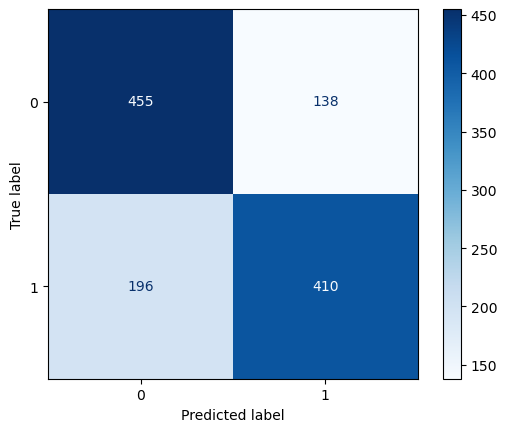

              precision    recall  f1-score   support

           0       0.70      0.77      0.73       593
           1       0.75      0.68      0.71       606

    accuracy                           0.72      1199
   macro avg       0.72      0.72      0.72      1199
weighted avg       0.72      0.72      0.72      1199



In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Make predictions using your model
vc_pred = model.predict(X_test)

# Print confusion matrix
print(confusion_matrix(y_test, vc_pred))

# Create and plot confusion matrix using ConfusionMatrixDisplay
conf_matrix = confusion_matrix(y_test, vc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap='Blues')  # Optional: You can change the color map here

# Show the plot
plt.show()

# Print classification report
print(classification_report(y_test, vc_pred))


## AdaBoost Classifier

In [78]:
ada = AdaBoostClassifier()
ada.fit(X_train,y_train)

AdaBoostClassifier()

In [79]:
ada_pred = ada.predict(X_test)
print(classification_report(y_test,ada_pred))

              precision    recall  f1-score   support

           0       0.57      0.62      0.60       593
           1       0.60      0.55      0.57       606

    accuracy                           0.58      1199
   macro avg       0.59      0.59      0.58      1199
weighted avg       0.59      0.58      0.58      1199



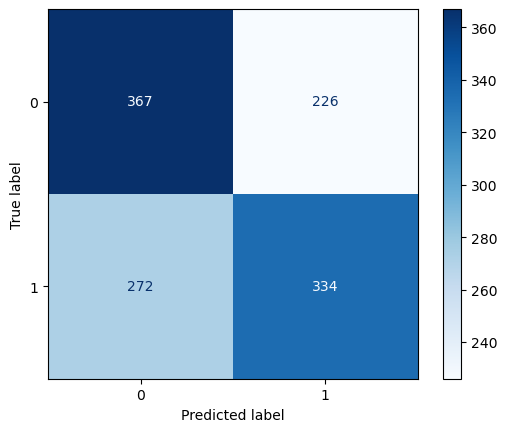

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions using AdaBoost model
ada_pred = ada.predict(X_test)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, ada_pred)

# Create ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=ada.classes_)

# Plot the confusion matrix
disp.plot(cmap='Blues')  # Optional: You can choose the color map here

# Show the plot
plt.show()


## CatBoost Classifier

In [81]:
catboost = CatBoostClassifier(random_state=1)
catboost.fit(X_train,y_train)

Learning rate set to 0.015983
0:	learn: 0.6913864	total: 4.78ms	remaining: 4.78s
1:	learn: 0.6900148	total: 8.59ms	remaining: 4.29s
2:	learn: 0.6885821	total: 12.2ms	remaining: 4.07s
3:	learn: 0.6871005	total: 15.9ms	remaining: 3.96s
4:	learn: 0.6857678	total: 19.5ms	remaining: 3.88s
5:	learn: 0.6843086	total: 23.2ms	remaining: 3.85s
6:	learn: 0.6829082	total: 26.8ms	remaining: 3.8s
7:	learn: 0.6816898	total: 30.3ms	remaining: 3.75s
8:	learn: 0.6801670	total: 33.9ms	remaining: 3.74s
9:	learn: 0.6785795	total: 38.1ms	remaining: 3.78s
10:	learn: 0.6770862	total: 42ms	remaining: 3.78s
11:	learn: 0.6756871	total: 46.2ms	remaining: 3.8s
12:	learn: 0.6742152	total: 50ms	remaining: 3.8s
13:	learn: 0.6728681	total: 54ms	remaining: 3.8s
14:	learn: 0.6716217	total: 58ms	remaining: 3.81s
15:	learn: 0.6707545	total: 62ms	remaining: 3.81s
16:	learn: 0.6696189	total: 66ms	remaining: 3.81s
17:	learn: 0.6682804	total: 69.8ms	remaining: 3.81s
18:	learn: 0.6668230	total: 73.8ms	remaining: 3.81s
19:	lear

In [82]:
catboost_pred = catboost.predict(X_test)
catboost_pred

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [83]:
print(confusion_matrix(y_test,catboost_pred))
print(classification_report(y_test,catboost_pred))

[[420 173]
 [192 414]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       593
           1       0.71      0.68      0.69       606

    accuracy                           0.70      1199
   macro avg       0.70      0.70      0.70      1199
weighted avg       0.70      0.70      0.70      1199



## Extra Trees Classifier

In [84]:
etc = ExtraTreesClassifier()
etc.fit(X_train,y_train)

ExtraTreesClassifier()

In [85]:
etc_pred = etc.predict(X_test)
print(classification_report(y_test,etc_pred))

              precision    recall  f1-score   support

           0       0.72      0.79      0.75       593
           1       0.77      0.70      0.74       606

    accuracy                           0.75      1199
   macro avg       0.75      0.75      0.75      1199
weighted avg       0.75      0.75      0.75      1199



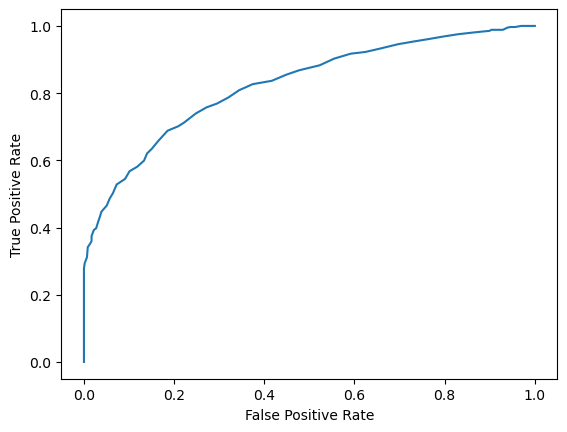

In [86]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_prob = etc.predict_proba(X_test)[:, 1]  # For binary classification, use the second column

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve using RocCurveDisplay
disp = RocCurveDisplay(fpr=fpr, tpr=tpr)
disp.plot()

# Show the plot
plt.show()


## Light GBM Classifier

In [87]:
lgbm = LGBMClassifier()
lgbm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 1392, number of negative: 1405
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2797, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497676 -> initscore=-0.009296
[LightGBM] [Info] Start training from score -0.009296


LGBMClassifier()

In [88]:
lgbm_pred = lgbm.predict(X_test)
print(classification_report(y_test,lgbm_pred))

              precision    recall  f1-score   support

           0       0.69      0.68      0.68       593
           1       0.69      0.69      0.69       606

    accuracy                           0.69      1199
   macro avg       0.69      0.69      0.69      1199
weighted avg       0.69      0.69      0.69      1199



## Histogram Gradient Boosting Classifier

In [89]:
hgbc = HistGradientBoostingClassifier()
hgbc.fit(X_train,y_train)

HistGradientBoostingClassifier()

In [90]:
hgbc_pred = hgbc.predict(X_test)
print(classification_report(y_test,hgbc_pred))

              precision    recall  f1-score   support

           0       0.68      0.68      0.68       593
           1       0.69      0.68      0.68       606

    accuracy                           0.68      1199
   macro avg       0.68      0.68      0.68      1199
weighted avg       0.68      0.68      0.68      1199



## Boosting Classifier

In [91]:
bag = BaggingClassifier()
bag.fit(X_train,y_train)

BaggingClassifier()

In [92]:
bag_pred = bag.predict(X_test)
print(classification_report(y_test,bag_pred))

              precision    recall  f1-score   support

           0       0.66      0.75      0.70       593
           1       0.71      0.62      0.67       606

    accuracy                           0.68      1199
   macro avg       0.69      0.68      0.68      1199
weighted avg       0.69      0.68      0.68      1199



## Model Performance Analysis

In [93]:
print('Accuracy Score of Logistic Regression:',str(np.round(accuracy_score(y_test,lr_pred)*100,2)) + '%')
print('Accuracy Score of SGD Classifier:',str(np.round(accuracy_score(y_test,sgd_pred)*100,2)) + '%')
print('Accuracy Score of Passive Aggressive Classifier:',str(np.round(accuracy_score(y_test,pac_pred)*100,2)) + '%')
print('Accuracy Score of Ridge Classifier:',str(np.round(accuracy_score(y_test,ridge_pred)*100,2)) + '%')
print('Accuracy Score of Gaussian Naive Bayes:',str(np.round(accuracy_score(y_test,gnb_pred)*100,2)) + '%')
print('Accuracy Score of Bernoulli Naive Bayes:',str(np.round(accuracy_score(y_test,bnb_pred)*100,2)) + '%')
print('Accuracy Score of K Neighbors Classifier:',str(np.round(accuracy_score(y_test,knc_pred)*100,2)) + '%')
print('Accuracy Score of Support Vector Classifier:',str(np.round(accuracy_score(y_test,svc_pred)*100,2)) + '%')
print('Accuracy Score of Decision Tree Classifier:',str(np.round(accuracy_score(y_test,dtree_pred)*100,2)) + '%')
print('Accuracy Score of Random Forest Classifier:',str(np.round(accuracy_score(y_test,rfc_pred)*100,2)) + '%')
print('Accuracy Score of XG Boost Classifier:',str(np.round(accuracy_score(y_test,xgb_pred)*100,2)) + '%')
print('Accuracy Score of Gradient Boosting Classifier:',str(np.round(accuracy_score(y_test,gbc_pred)*100,2)) + '%')
print('Accuracy Score of Voting Classifier:',str(np.round(accuracy_score(y_test,vc_pred)*100,2)) + '%')
print('Accuracy Score of CatBoost Classifier:',str(np.round(accuracy_score(y_test,catboost_pred)*100,2)) + '%')
print('Accuracy Score of AdaBoost Classifier:',str(np.round(accuracy_score(y_test,ada_pred)*100,2)) + '%')
print('Accuracy Score of Extra Trees Classifier:',str(np.round(accuracy_score(y_test,etc_pred)*100,2)) + '%')
print('Accuracy Score of LGBM Classifier:',str(np.round(accuracy_score(y_test,lgbm_pred)*100,2)) + '%')
print('Accuracy Score of Hist Gradient Boosting Classifier:',str(np.round(accuracy_score(y_test,hgbc_pred)*100,2)) + '%')
print('Accuracy Score of Bagging Classifier:',str(np.round(accuracy_score(y_test,bag_pred)*100,2)) + '%')

Accuracy Score of Logistic Regression: 50.79%
Accuracy Score of SGD Classifier: 50.88%
Accuracy Score of Passive Aggressive Classifier: 52.79%
Accuracy Score of Ridge Classifier: 50.79%
Accuracy Score of Gaussian Naive Bayes: 56.3%
Accuracy Score of Bernoulli Naive Bayes: 50.38%
Accuracy Score of K Neighbors Classifier: 71.14%
Accuracy Score of Support Vector Classifier: 67.31%
Accuracy Score of Decision Tree Classifier: 61.47%
Accuracy Score of Random Forest Classifier: 73.56%
Accuracy Score of XG Boost Classifier: 68.47%
Accuracy Score of Gradient Boosting Classifier: 64.14%
Accuracy Score of Voting Classifier: 72.14%
Accuracy Score of CatBoost Classifier: 69.56%
Accuracy Score of AdaBoost Classifier: 58.47%
Accuracy Score of Extra Trees Classifier: 74.56%
Accuracy Score of LGBM Classifier: 68.72%
Accuracy Score of Hist Gradient Boosting Classifier: 68.22%
Accuracy Score of Bagging Classifier: 68.39%


Extra Trees Classifier produced the best performance among all models with the highest prediction accuracy of almost 75.5%.

## Hyperparameter Tuning using Cross Validation

In [94]:
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
svc = SVC()
xgb = XGBClassifier(eval_metric = 'logloss', use_label_encoder=False)

#KNN
para_knn = {'n_neighbors':np.arange(1, 50)}  #parameters of knn
grid_knn = GridSearchCV(knn, param_grid=para_knn, cv=5) #search knn for 5 fold cross validation

#Decision Tree
para_dt = {'criterion':['gini','entropy'], 'max_depth':np.arange(1, 50), 'min_samples_leaf':[1,2,4,5,10,20,30,40,80,100]}
grid_dt = GridSearchCV(dt, param_grid=para_dt, cv=5) #grid search decision tree for 5 fold cv

#Random Forest
params_rf = {'n_estimators':[100,200, 350, 500], 'min_samples_leaf':[2, 10, 30]}
grid_rf = GridSearchCV(rf, param_grid=params_rf, cv=5)

#SVC
params_svc = {'C': [.1,1,10,100,1000,10000], 'gamma': [.1,0.01,0.001,0.0001], 'kernel': ['rbf']}
grid_svc = GridSearchCV(svc, param_grid = params_svc, cv=5)

#XGBoost
params_xgb = {'n_estimators': [50,100,250,400,600,800,1000], 'learning_rate': [0.2,0.5,0.8,1]}
rs_xgb =  RandomizedSearchCV(xgb, param_distributions=params_xgb, cv=5)

In [98]:
grid_knn.fit(X_train, y_train)
grid_dt.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)
grid_svc.fit(X_train, y_train)
rs_xgb.fit(X_train, y_train)

print("Best parameters for KNN:", grid_knn.best_params_)
print("Best parameters for Decision Tree:", grid_dt.best_params_)
print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best parameters for SVC:", grid_svc.best_params_)
print("Best parameters for XGBoost:", rs_xgb.best_params_)

Best parameters for KNN: {'n_neighbors': 1}
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 40, 'min_samples_leaf': 1}
Best parameters for Random Forest: {'min_samples_leaf': 2, 'n_estimators': 500}
Best parameters for SVC: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best parameters for XGBoost: {'n_estimators': 250, 'learning_rate': 0.2}


## Saving the model for future use

In [99]:
joblib.dump(etc,'model.pkl')

['model.pkl']

In [100]:
model = joblib.load('model.pkl')
model

ExtraTreesClassifier()